# Seed 00: multi-epsilon_ff spread analysis
## Static 1 Myr CMD color bins, global 3000--3600 K cut, one instantaneous control

Finite models: epsilon_ff = 0.01, 0.03, 0.10, 0.30, 1.00, all seed 00.
The single instantaneous control is constructed ONLY from epsilon_ff=0.03, seed 00.

CMDs retained: F070W-F200W vs F200W, F182M-F200W vs F200W,
HST F555W-F814W vs F814W.  The HR diagram is retained as the physical-space
comparison.  F140M-F162M vs F162M is intentionally removed.

For each CMD, the six equal-width COLOR bins are defined once from the colors
corresponding to Teff=3000 K and Teff=3600 K on the 1 Myr isochrone.  These
fixed edges are then reused for every epsilon_ff and every snapshot.

At each snapshot, stars are eligible only when 3000 <= Teff <= 3600 K.
Temperature is a GLOBAL eligibility cut only; an eligible star is assigned to
a bin solely by its ACTUAL CMD color.

Raw spread curves contain all five finite epsilon_ff values plus the single
instantaneous control.  Normalized curves use S(epsilon_ff)/S(infinity) at
the same time and diagram.  Ratios are omitted when the instantaneous baseline
is non-finite or effectively zero; baseline-subtracted excess spread is also
saved as a diagnostic.

In [1]:
from __future__ import annotations

import contextlib
import io
import json
import math
import os
import shutil
import sys
import warnings
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.table import Column, Table

from spisea import atmospheres, reddening, synthetic
from nbody6tools import Reader
from nbody62spisea import converter

sys.path.append('/home/wyz5rge/synthetic-cmd-dev/cmd_generator')
import interpolator  # noqa: E402

/home/wyz5rge/.venv/nbody/lib/python3.11/site-packages/pysynphot/locations.py:345: UserWarning: Extinction files not found in /home/wyz5rge/SPISEA/cdbs/extinction
  warnings.warn('Extinction files not found in %s' % (extdir, ))


particles.bound_subset and particles.bound_indexes will raise ImportError


## Configuration

In [2]:
UPDATED_MERGED_ROOT = Path(
    '/home/wyz5rge/SPISEA/evolution/merged/'
    'baraffe_pisa_ekstrom_parsec/'
)

SIMULATION_ROOT = Path(
    '/standard/Tan_JC/backup_protoclusters/multiples/M3000new/'
    'sigma0p1/fiducial'
)

EFF_CONFIG = {
    0.01: 'sfe_ff001',
    0.03: 'sfe_ff003',
    0.10: 'sfe_ff010',
    0.30: 'sfe_ff030',
    1.00: 'sfe_ff100',
}
SEED = '00'
SIMULATION_PATHS = {
    eff: SIMULATION_ROOT / dirname / SEED
    for eff, dirname in EFF_CONFIG.items()
}

INSTANTANEOUS_SOURCE_EFF = 0.03
INSTANTANEOUS_SOURCE_PATH = SIMULATION_PATHS[INSTANTANEOUS_SOURCE_EFF]

OUTPUT_DIR = Path.cwd() / 'seed00_all_eff_static_1myr_bins_outputs'
CACHE_DIR = Path.cwd() / 'analysis_cache_all_eff_seed00'
ISO_CACHE_DIR = Path.cwd() / 'iso_cache'
MASTER_DIR = CACHE_DIR / 'instantaneous_master_eff003'
FINITE_CACHE_ROOT = CACHE_DIR / 'finite_catalogs'
INFINITE_DIR = CACHE_DIR / 'instantaneous_eff003'
METRIC_DIR = CACHE_DIR / 'metrics_static_1myr_color_bins'

RESET_ISO_CACHE = False
RECOMPUTE_MASTER = False
RECOMPUTE_FINITE = False
RECOMPUTE_INFINITE = False
RECOMPUTE_METRICS = False

SAVE_FIGURES = True
SHOW_FIGURES = True

USE_ROTATING_MERGED = False
AKS = 0.0
DISTANCE_PC = 410.0
METALLICITY = 0.0
ATM_FUNC = atmospheres.get_BTSettl_2015_atmosphere
RED_LAW = reddening.RedLawHosek18b()

ISO_AGES_MYR = np.arange(1.0, 20.0 + 0.25, 0.5)
ISO_LOG_AGES = np.log10(ISO_AGES_MYR * 1.0e6)

ANALYSIS_TIMES_MYR = np.arange(1.0, 20.0 + 0.25, 0.5)
DISPLAY_TIMES_MYR = np.array(
    [1.0, 2.0, 3.0, 5.0, 7.5, 10.0, 15.0, 20.0]
)

TEFF_MIN_K = 3000.0
TEFF_MAX_K = 3600.0
N_BINS = 6

# HR diagram x-bin edges.  CMDs DO NOT use these as bin edges.
HR_TEFF_BIN_EDGES_K = np.linspace(
    TEFF_MIN_K,
    TEFF_MAX_K,
    N_BINS + 1,
)

MIN_STARS_PER_BIN = 8
NORMALIZATION_MIN_BASELINE = 1.0e-8
CLIP_YOUNG_TO_GRID = True

BIN_CMAP = plt.get_cmap('viridis')
L_SUN_WATTS = 3.846e26

FILTER_OBSMODES = {
    'F070W': 'jwst,F070W',
    'F182M': 'jwst,F182M',
    'F200W': 'jwst,F200W',
    'F555W': 'wfc3,uvis1,f555w',
    'F814W': 'wfc3,uvis1,f814w',
}

ALL_FILTERS = list(FILTER_OBSMODES.values())

FINITE_CASES = {eff: f'finite_eff{eff:g}' for eff in EFF_CONFIG}
INFINITE = 'instantaneous_eff003'
CASE_TO_EFF = {case: eff for eff, case in FINITE_CASES.items()}
CASE_LABEL = {
    **{case: rf'$\epsilon_{{\rm ff}}={eff:g}$' for eff, case in FINITE_CASES.items()},
    INFINITE: r'$\epsilon_{\rm ff}=\infty$',
}
CASE_ORDER = [FINITE_CASES[eff] for eff in EFF_CONFIG] + [INFINITE]

## Diagram definitions

In [3]:
@dataclass(frozen=True)
class Diagram:
    key: str
    title: str
    xlabel: str
    ylabel: str
    kind: str
    blue: str | None = None
    red: str | None = None
    y_filter: str | None = None
    invert_x: bool = False
    invert_y: bool = False


DIAGRAMS = [
    Diagram(
        'hr',
        r'$\log(L/L_\odot)$ vs. $T_{\rm eff}$',
        r'$T_{\rm eff}$ [K]',
        r'$\log(L/L_\odot)$',
        'hr',
        invert_x=True,
    ),
    Diagram(
        'f070w_f200w',
        'F070W - F200W vs. F200W',
        'F070W - F200W',
        'F200W',
        'cmd',
        'F070W',
        'F200W',
        'F200W',
        invert_y=True,
    ),
    Diagram(
        'f182m_f200w',
        'F182M - F200W vs. F200W',
        'F182M - F200W',
        'F200W',
        'cmd',
        'F182M',
        'F200W',
        'F200W',
        invert_y=True,
    ),
    Diagram(
        'hst_f555w_f814w',
        'HST F555W - F814W vs. F814W',
        'F555W - F814W',
        'F814W',
        'cmd',
        'F555W',
        'F814W',
        'F814W',
        invert_y=True,
    ),
]

## General helpers

In [4]:
def show_table(df, n=None):
    if n is not None:
        df = df.head(n)

    try:
        from IPython.display import display
        display(df)
    except Exception:
        print(df.to_string(index=False))


def finite_cache_dir(eff):
    return FINITE_CACHE_ROOT / EFF_CONFIG[eff]


def prepare_dirs():
    if RESET_ISO_CACHE and ISO_CACHE_DIR.exists():
        shutil.rmtree(ISO_CACHE_DIR)

    for path in [
        OUTPUT_DIR,
        CACHE_DIR,
        ISO_CACHE_DIR,
        MASTER_DIR,
        FINITE_CACHE_ROOT,
        INFINITE_DIR,
        METRIC_DIR,
    ]:
        path.mkdir(
            parents=True,
            exist_ok=True,
        )

    for eff in EFF_CONFIG:
        finite_cache_dir(eff).mkdir(parents=True, exist_ok=True)


def finish_figure(fig, filename):
    if SAVE_FIGURES:
        fig.savefig(
            OUTPUT_DIR / filename,
            dpi=220,
            bbox_inches='tight',
        )

    if SHOW_FIGURES:
        plt.show()
    else:
        plt.close(fig)


def normalize_name(value):
    return ''.join(
        ch.lower()
        for ch in str(value)
        if ch.isalnum()
    )


def canonical_name(value: Any) -> str:
    if isinstance(value, bytes):
        return value.decode(
            'utf-8',
            errors='replace',
        ).strip()

    if isinstance(value, (int, np.integer)):
        return str(int(value))

    return str(value).strip()

## Merged evolutionary-model reader

In [5]:
class MergedBaraffePisaEkstromParsecDAT:
    def __init__(
        self,
        root_dir: Path | str,
        rot: bool = False,
    ):
        self.root_dir = Path(
            root_dir
        ).expanduser().resolve()

        self.rot = bool(rot)
        self.model_dir = str(self.root_dir)
        self.z_list = [0.015]
        self.z_solar = 0.015
        self.mass_list = []

        self.grid_dir = self.root_dir / (
            'z015_rot'
            if rot
            else 'z015_norot'
        )

        if not self.grid_dir.is_dir():
            raise FileNotFoundError(
                self.grid_dir
            )

        self.age_file_map = {}

        for path in sorted(
            self.grid_dir.glob('iso_*.dat')
        ):
            try:
                log_age = float(
                    path.stem.split('_')[1]
                )
            except (IndexError, ValueError):
                continue

            self.age_file_map[
                round(log_age, 2)
            ] = path

        if not self.age_file_map:
            raise FileNotFoundError(
                f'No iso_*.dat files in {self.grid_dir}'
            )

        self.age_list = np.array(
            sorted(self.age_file_map),
            dtype=float,
        )

    def isochrone(
        self,
        age: float = 1.0e6,
        metallicity: float = 0.0,
    ) -> Table:
        requested = math.log10(age)

        if (
            requested < self.age_list[0]
            or requested > self.age_list[-1]
        ):
            raise ValueError(
                f'logAge {requested:.4f} '
                'outside merged grid'
            )

        idx = int(
            np.argmin(
                np.abs(
                    self.age_list
                    - requested
                )
            )
        )

        selected = float(
            self.age_list[idx]
        )

        path = self.age_file_map[
            round(selected, 2)
        ]

        dtype = [
            ('mass', 'f8'),
            ('logT', 'f8'),
            ('logL', 'f8'),
            ('logg', 'f8'),
            ('logT_WR', 'f8'),
            ('mass_current', 'f8'),
            ('phase', 'i4'),
            ('model_ref', 'U32'),
        ]

        data = np.genfromtxt(
            path,
            comments='#',
            dtype=dtype,
            encoding='utf-8',
        )

        iso = Table(
            np.atleast_1d(data)
        )

        iso.add_column(
            Column(
                ~np.isclose(
                    np.asarray(
                        iso['logT'],
                        float,
                    ),
                    np.asarray(
                        iso['logT_WR'],
                        float,
                    ),
                    rtol=0.0,
                    atol=1.0e-8,
                ),
                name='isWR',
            )
        )

        iso.meta.update({
            'log_age': selected,
            'log_age_requested': requested,
            'metallicity_in': metallicity,
            'metallicity_act': 0.0,
            'source_file': str(path),
        })

        return iso

## Isochrone helpers

In [6]:
@dataclass
class IsoGrid:
    ages_myr: np.ndarray
    log_ages: np.ndarray
    isochrones: list
    coverage: pd.DataFrame
    filter_columns: dict[str, str]


def resolve_filter_column(
    colnames,
    filter_name,
):
    target = normalize_name(
        filter_name
    )

    candidates = [
        c
        for c in colnames
        if normalize_name(c).startswith('m')
        and normalize_name(c).endswith(target)
    ]

    instrument = (
        'hst'
        if filter_name in {'F555W', 'F814W'}
        else 'jwst'
    )

    preferred = [
        c
        for c in candidates
        if instrument in normalize_name(c)
    ]

    if len(preferred) == 1:
        return preferred[0]

    if len(candidates) == 1:
        return candidates[0]

    raise KeyError(
        f'Cannot resolve {filter_name}; '
        f'candidates={candidates}; '
        f'available={list(colnames)}'
    )


def safe_interpolate(
    age_myr,
    mass,
    grid,
    log_ages,
    filters,
):
    try:
        with warnings.catch_warnings(), \
                contextlib.redirect_stdout(
                    io.StringIO()
                ), \
                contextlib.redirect_stderr(
                    io.StringIO()
                ):

            warnings.simplefilter(
                'ignore'
            )

            result = interpolator.interpolate(
                age_myr,
                mass,
                grid,
                log_ages,
                list(filters),
            )

        if result is None:
            return None

        result = np.asarray(
            result,
            float,
        )

        if (
            result.size
            != 3 + len(filters)
            or not np.all(
                np.isfinite(result)
            )
        ):
            return None

        return result

    except Exception:
        return None


def build_iso_grid(evo_model):
    isochrones = []
    records = []
    filter_columns = None

    for age_myr, log_age in zip(
        ISO_AGES_MYR,
        ISO_LOG_AGES,
    ):
        print(
            f'Building/loading '
            f'{age_myr:4.1f} Myr isochrone'
        )

        try:
            iso = synthetic.IsochronePhot(
                log_age,
                AKS,
                DISTANCE_PC,
                metallicity=METALLICITY,
                evo_model=evo_model,
                atm_func=ATM_FUNC,
                red_law=RED_LAW,
                filters=ALL_FILTERS,
                iso_dir=str(
                    ISO_CACHE_DIR
                ),
            )

            current = {
                name: resolve_filter_column(
                    iso.points.colnames,
                    name,
                )
                for name in FILTER_OBSMODES
            }

            if filter_columns is None:
                filter_columns = current

                print(
                    'Resolved magnitude columns:'
                )

                for name, column in current.items():
                    print(
                        f'  {name}: {column}'
                    )

            elif current != filter_columns:
                raise RuntimeError(
                    'Magnitude columns '
                    'changed across ages'
                )

            mass = np.asarray(
                iso.points['mass'],
                float,
            )

            isochrones.append(
                iso
            )

            records.append({
                'age_myr': age_myr,
                'status': 'success',
                'n_points': len(
                    iso.points
                ),
                'mass_min': np.nanmin(
                    mass
                ),
                'mass_max': np.nanmax(
                    mass
                ),
                'error': '',
            })

        except Exception as exc:
            isochrones.append(
                None
            )

            records.append({
                'age_myr': age_myr,
                'status': 'failed',
                'n_points': 0,
                'mass_min': np.nan,
                'mass_max': np.nan,
                'error': str(exc),
            })

            print(
                f'  FAILED: {exc}'
            )

    if filter_columns is None:
        raise RuntimeError(
            'No isochrones were built'
        )

    return IsoGrid(
        ISO_AGES_MYR.copy(),
        ISO_LOG_AGES.copy(),
        isochrones,
        pd.DataFrame(records),
        filter_columns,
    )

In [7]:
prepare_dirs()

for eff, simulation_path in SIMULATION_PATHS.items():
    if not simulation_path.is_dir():
        raise FileNotFoundError(
            f'epsilon_ff={eff:g}: {simulation_path}'
        )

evo_model = (
    MergedBaraffePisaEkstromParsecDAT(
        UPDATED_MERGED_ROOT,
        rot=USE_ROTATING_MERGED,
    )
)

ISO_GRID = build_iso_grid(
    evo_model
)

show_table(
    ISO_GRID.coverage
)

failed = ISO_GRID.coverage[
    ISO_GRID.coverage[
        'status'
    ] != 'success'
]

if len(failed):
    raise RuntimeError(
        'Isochrone failures:\n'
        + failed[
            ['age_myr', 'error']
        ].to_string(
            index=False
        )
    )

Building/loading  1.0 Myr isochrone
Resolved magnitude columns:
  F070W: m_jwst_F070W
  F182M: m_jwst_F182M
  F200W: m_jwst_F200W
  F555W: m_hst_f555w
  F814W: m_hst_f814w
Building/loading  1.5 Myr isochrone
Building/loading  2.0 Myr isochrone
Building/loading  2.5 Myr isochrone
Building/loading  3.0 Myr isochrone
Building/loading  3.5 Myr isochrone
Building/loading  4.0 Myr isochrone


Building/loading  4.5 Myr isochrone
Building/loading  5.0 Myr isochrone
Building/loading  5.5 Myr isochrone
Building/loading  6.0 Myr isochrone
Building/loading  6.5 Myr isochrone
Building/loading  7.0 Myr isochrone
Building/loading  7.5 Myr isochrone
Building/loading  8.0 Myr isochrone


Building/loading  8.5 Myr isochrone
Building/loading  9.0 Myr isochrone
Building/loading  9.5 Myr isochrone
Building/loading 10.0 Myr isochrone
Building/loading 10.5 Myr isochrone
Building/loading 11.0 Myr isochrone
Building/loading 11.5 Myr isochrone


Building/loading 12.0 Myr isochrone
Building/loading 12.5 Myr isochrone
Building/loading 13.0 Myr isochrone
Building/loading 13.5 Myr isochrone
Building/loading 14.0 Myr isochrone
Building/loading 14.5 Myr isochrone
Building/loading 15.0 Myr isochrone
Building/loading 15.5 Myr isochrone


Building/loading 16.0 Myr isochrone
Building/loading 16.5 Myr isochrone
Building/loading 17.0 Myr isochrone
Building/loading 17.5 Myr isochrone
Building/loading 18.0 Myr isochrone
Building/loading 18.5 Myr isochrone
Building/loading 19.0 Myr isochrone


Building/loading 19.5 Myr isochrone
Building/loading 20.0 Myr isochrone


,age_myr,status,n_points,mass_min,mass_max,error
0,1.0,success,1178,0.01,500.000,
1,1.5,success,1287,0.01,500.000,
2,2.0,success,1330,0.01,500.000,
3,2.5,success,2333,0.01,259.154,
4,3.0,success,1856,0.01,116.520,
5,3.5,success,1884,0.01,80.336,
6,4.0,success,1704,0.01,58.761,
7,4.5,success,1571,0.01,47.174,
8,5.0,success,1529,0.01,39.109,
9,5.5,success,1525,0.01,34.304,


## Snapshot loading with exact persistent identifiers

In [8]:
def load_cluster_table(
    sim_path,
    snapshot_time_myr,
):
    path = os.path.abspath(
        str(sim_path)
    )

    if not path.endswith('/'):
        path += '/'

    snapshot = Reader.read_snapshot(
        path,
        time=float(
            snapshot_time_myr
        ),
    )

    snapshot.to_physical()

    table = converter.to_spicea_table(
        snapshot
    )

    bdict = Reader.read_binaries(
        path,
        snapshot=snapshot.snapshot,
        single_dict=True,
    )

    primary_names = np.asarray(
        bdict['primary'],
        dtype=int,
    )

    secondary_names = np.asarray(
        bdict['secondary'],
        dtype=int,
    )

    binary_component_names = (
        np.concatenate([
            primary_names,
            secondary_names,
        ])
    )

    single_mask = ~np.isin(
        np.asarray(
            snapshot.stars.name,
            dtype=int,
        ),
        binary_component_names,
    )

    singles = snapshot.stars[
        single_mask
    ]

    single_names = np.asarray(
        singles.name,
        dtype=int,
    )

    system_names = np.concatenate([
        single_names,
        primary_names,
    ])

    companion_names = np.full(
        len(table),
        -1,
        dtype=int,
    )

    companion_names[
        len(single_names):
    ] = secondary_names

    if len(system_names) != len(table):
        raise RuntimeError(
            'Identifier reconstruction '
            'does not match converter output: '
            f'{len(system_names)} identifiers '
            f'versus {len(table)} rows.'
        )

    expected_multiple = np.concatenate([
        np.zeros(
            len(single_names),
            dtype=bool,
        ),
        np.ones(
            len(primary_names),
            dtype=bool,
        ),
    ])

    actual_multiple = (
        np.asarray(
            table['isMultiple'],
            float,
        ) > 0
    )

    if not np.array_equal(
        expected_multiple,
        actual_multiple,
    ):
        raise RuntimeError(
            'Reconstructed single/binary '
            'ordering disagrees with converter output'
        )

    table.add_column(
        Column(
            system_names,
            name='system_name',
        ),
        index=0,
    )

    table.add_column(
        Column(
            system_names,
            name='primary_name',
        ),
        index=1,
    )

    table.add_column(
        Column(
            companion_names,
            name='companion_name',
        ),
        index=2,
    )

    table.meta[
        'requested_snapshot_time_myr'
    ] = float(
        snapshot_time_myr
    )

    return table

## Instantaneous master catalog

In [9]:
MASTER_PATH = (
    MASTER_DIR
    / 'master_catalog.csv'
)

N_PRIMORDIAL_COMPONENTS = 150


def parse_gradual_formation_file(
    simulation_path: Path | str,
):
    gradual_path = (
        Path(simulation_path)
        / 'gradual.97'
    )

    if not gradual_path.is_file():
        raise FileNotFoundError(
            gradual_path
        )

    singles = []
    binaries = []

    with gradual_path.open() as handle:
        for line_number, line in enumerate(
            handle,
            start=1,
        ):
            fields = line.strip().split()

            if (
                not fields
                or len(fields) < 2
                or fields[1] == 'TIME'
            ):
                continue

            record_type = fields[
                0
            ].upper()

            if record_type == 'SINGLE':
                name = int(
                    fields[3]
                )

                mass = float(
                    fields[4]
                )

                singles.append({
                    'system_name': name,
                    'primary_name': name,
                    'companion_name': -1,
                    'is_multiple': False,
                    'primary_initial_mass': mass,
                    'companion_initial_mass': np.nan,
                    'system_initial_mass': mass,
                    'original_birth_time_myr': float(
                        fields[2]
                    ),
                    'source': 'gradual.97',
                    'source_line': line_number,
                })

            elif record_type == 'BINARY':
                primary = int(
                    fields[3]
                )

                secondary = int(
                    fields[4]
                )

                m1 = float(
                    fields[5]
                )

                m2 = float(
                    fields[6]
                )

                binaries.append({
                    'system_name': primary,
                    'primary_name': primary,
                    'companion_name': secondary,
                    'is_multiple': True,
                    'primary_initial_mass': m1,
                    'companion_initial_mass': m2,
                    'system_initial_mass': m1 + m2,
                    'original_birth_time_myr': float(
                        fields[2]
                    ),
                    'source': 'gradual.97',
                    'source_line': line_number,
                })

    return singles, binaries


def primordial_snapshot_zero_systems(
    simulation_path: Path | str,
) -> pd.DataFrame:
    data = converter.get_binary_data(
        os.path.abspath(
            str(simulation_path)
        ),
        0,
    )

    single_names = np.asarray(
        data['single'],
        int,
    )

    single_masses = np.asarray(
        data['msingle'],
        float,
    )

    primary_names = np.asarray(
        data['primary'],
        int,
    )

    secondary_names = np.asarray(
        data['secondary'],
        int,
    )

    primary_masses = np.asarray(
        data['m1'],
        float,
    )

    secondary_masses = np.asarray(
        data['m2'],
        float,
    )

    binary_mask = (
        (primary_names >= 1)
        & (
            primary_names
            <= N_PRIMORDIAL_COMPONENTS
        )
        & (secondary_names >= 1)
        & (
            secondary_names
            <= N_PRIMORDIAL_COMPONENTS
        )
    )

    primary_names = primary_names[
        binary_mask
    ]

    secondary_names = secondary_names[
        binary_mask
    ]

    primary_masses = primary_masses[
        binary_mask
    ]

    secondary_masses = secondary_masses[
        binary_mask
    ]

    binary_components = (
        np.concatenate([
            primary_names,
            secondary_names,
        ])
    )

    true_single_mask = (
        (single_names >= 1)
        & (
            single_names
            <= N_PRIMORDIAL_COMPONENTS
        )
        & ~np.isin(
            single_names,
            binary_components,
        )
    )

    singles = pd.DataFrame({
        'system_name': single_names[
            true_single_mask
        ],
        'primary_name': single_names[
            true_single_mask
        ],
        'companion_name': -1,
        'is_multiple': False,
        'primary_initial_mass': single_masses[
            true_single_mask
        ],
        'companion_initial_mass': np.nan,
        'system_initial_mass': single_masses[
            true_single_mask
        ],
        'original_birth_time_myr': 0.0,
        'source': 'snapshot_0_primordial_single',
        'source_line': -1,
    })

    binaries = pd.DataFrame({
        'system_name': primary_names,
        'primary_name': primary_names,
        'companion_name': secondary_names,
        'is_multiple': True,
        'primary_initial_mass': primary_masses,
        'companion_initial_mass': secondary_masses,
        'system_initial_mass': (
            primary_masses
            + secondary_masses
        ),
        'original_birth_time_myr': 0.0,
        'source': 'snapshot_0_primordial_binary',
        'source_line': -1,
    })

    primordial = pd.concat(
        [singles, binaries],
        ignore_index=True,
    )

    component_names = np.concatenate([
        primordial[
            'primary_name'
        ].to_numpy(int),
        primordial.loc[
            primordial[
                'is_multiple'
            ].astype(bool),
            'companion_name',
        ].to_numpy(int),
    ])

    expected_names = set(
        range(
            1,
            N_PRIMORDIAL_COMPONENTS + 1,
        )
    )

    if set(
        component_names.tolist()
    ) != expected_names:
        raise RuntimeError(
            'Primordial reconstruction '
            'did not recover NAME 1--150 exactly'
        )

    if (
        pd.Series(
            component_names
        ).duplicated().any()
    ):
        raise RuntimeError(
            'Duplicate primordial component NAME values'
        )

    return primordial


def validate_master_catalog(
    master,
):
    binary_mask = master[
        'is_multiple'
    ].astype(bool)

    component_names = np.concatenate([
        master[
            'primary_name'
        ].to_numpy(int),
        master.loc[
            binary_mask,
            'companion_name',
        ].to_numpy(int),
    ])

    if (
        pd.Series(
            component_names
        ).duplicated().any()
    ):
        raise RuntimeError(
            'Duplicate component NAME values remain'
        )


def build_instantaneous_master_catalog(
    simulation_path,
):
    primordial = (
        primordial_snapshot_zero_systems(
            simulation_path
        )
    )

    gradual_singles, gradual_binaries = (
        parse_gradual_formation_file(
            simulation_path
        )
    )

    gradual = pd.DataFrame(
        gradual_singles
        + gradual_binaries
    )

    overlap = (
        gradual[
            'primary_name'
        ].between(
            1,
            N_PRIMORDIAL_COMPONENTS,
        )
        | (
            gradual[
                'is_multiple'
            ].astype(bool)
            & gradual[
                'companion_name'
            ].between(
                1,
                N_PRIMORDIAL_COMPONENTS,
            )
        )
    )

    gradual = gradual.loc[
        ~overlap
    ].copy()

    master = pd.concat(
        [primordial, gradual],
        ignore_index=True,
    )

    master[
        'instantaneous_birth_time_myr'
    ] = 0.0

    master = master.sort_values(
        [
            'original_birth_time_myr',
            'is_multiple',
            'system_name',
        ],
        kind='stable',
    ).reset_index(
        drop=True
    )

    validate_master_catalog(
        master
    )

    return master


if (
    MASTER_PATH.exists()
    and not RECOMPUTE_MASTER
):
    print(
        'Loading cached instantaneous '
        'master catalog'
    )

    df_master = pd.read_csv(
        MASTER_PATH
    )

    if (
        df_master[
            'is_multiple'
        ].dtype == object
    ):
        df_master[
            'is_multiple'
        ] = (
            df_master[
                'is_multiple'
            ]
            .astype(str)
            .str.lower()
            .map({
                'true': True,
                'false': False,
            })
        )

    validate_master_catalog(
        df_master
    )

else:
    print(
        'Building instantaneous '
        'master catalog'
    )

    df_master = (
        build_instantaneous_master_catalog(
            INSTANTANEOUS_SOURCE_PATH
        )
    )

    df_master.to_csv(
        MASTER_PATH,
        index=False,
    )

Building instantaneous master catalog


## Interpolated catalogs

This is intentionally unchanged from the original analysis so the existing
expensive cache can be reused.

In [10]:
FILTER_NAMES = list(
    FILTER_OBSMODES
)

FILTER_KEYS = [
    ISO_GRID.filter_columns[name]
    for name in FILTER_NAMES
]

CATALOG_COLUMNS = [
    'case',
    'system_index',
    'system_name',
    'primary_name',
    'companion_name',
    'is_multiple',
    'mass',
    'age_myr',
    'age_used_myr',
    'age_clipped_to_grid',
    'teff',
    'luminosity_watts',
    'log_luminosity_lsun',
    'logg',
    *[
        f'mag_{name}'
        for name in FILTER_NAMES
    ],
]


def cache_paths(
    case,
    time_myr,
):
    if case == INFINITE:
        directory = INFINITE_DIR
    else:
        directory = finite_cache_dir(CASE_TO_EFF[case])

    return (
        directory / f'catalog_t{time_myr:04.1f}myr.csv',
        directory / f'accounting_t{time_myr:04.1f}myr.json',
    )


def interpolate_arrays(
    case,
    system_names,
    primary_names,
    companion_names,
    is_multiple,
    masses,
    ages,
):
    rows = []

    counters = {
        'nonfinite_mass': 0,
        'nonfinite_age': 0,
        'younger_than_grid': 0,
        'older_than_grid': 0,
        'interpolation_failed': 0,
        'nonpositive_luminosity': 0,
        'retained': 0,
    }

    min_age = float(
        ISO_GRID.ages_myr.min()
    )

    max_age = float(
        ISO_GRID.ages_myr.max()
    )

    for idx, values in enumerate(
        zip(
            system_names,
            primary_names,
            companion_names,
            is_multiple,
            masses,
            ages,
        )
    ):
        (
            system_name,
            primary_name,
            companion_name,
            multiple,
            mass,
            age,
        ) = values

        if not np.isfinite(mass):
            counters[
                'nonfinite_mass'
            ] += 1
            continue

        if not np.isfinite(age):
            counters[
                'nonfinite_age'
            ] += 1
            continue

        used_age = float(age)
        clipped = False

        if used_age < min_age:
            counters[
                'younger_than_grid'
            ] += 1

            if not CLIP_YOUNG_TO_GRID:
                continue

            used_age = min_age
            clipped = True

        if used_age > max_age:
            counters[
                'older_than_grid'
            ] += 1
            continue

        result = safe_interpolate(
            used_age,
            float(mass),
            ISO_GRID.isochrones,
            ISO_GRID.log_ages,
            FILTER_KEYS,
        )

        if result is None:
            counters[
                'interpolation_failed'
            ] += 1
            continue

        luminosity, teff, logg = map(
            float,
            result[:3],
        )

        if luminosity <= 0:
            counters[
                'nonpositive_luminosity'
            ] += 1
            continue

        row = {
            'case': case,
            'system_index': idx,
            'system_name': canonical_name(
                system_name
            ),
            'primary_name': canonical_name(
                primary_name
            ),
            'companion_name': canonical_name(
                companion_name
            ),
            'is_multiple': bool(
                multiple
            ),
            'mass': float(
                mass
            ),
            'age_myr': float(
                age
            ),
            'age_used_myr': used_age,
            'age_clipped_to_grid': clipped,
            'teff': teff,
            'luminosity_watts': luminosity,
            'log_luminosity_lsun': np.log10(
                luminosity
                / L_SUN_WATTS
            ),
            'logg': logg,
        }

        row.update({
            f'mag_{name}': float(value)
            for name, value in zip(
                FILTER_NAMES,
                result[3:],
            )
        })

        rows.append(
            row
        )

        counters[
            'retained'
        ] += 1

    df = pd.DataFrame(
        rows,
        columns=CATALOG_COLUMNS,
    )

    df.attrs[
        'counters'
    ] = counters

    return df


def finite_catalog(
    eff,
    time_myr,
):
    case = FINITE_CASES[eff]
    table = load_cluster_table(
        SIMULATION_PATHS[eff],
        time_myr,
    )

    df = interpolate_arrays(
        case,
        np.asarray(
            table['system_name'],
            int,
        ),
        np.asarray(
            table['primary_name'],
            int,
        ),
        np.asarray(
            table['companion_name'],
            int,
        ),
        np.asarray(
            table['isMultiple'],
            float,
        ) > 0,
        np.asarray(
            table['mass'],
            float,
        ),
        np.asarray(
            table['age'],
            float,
        ),
    )

    return df, len(table)


def infinite_catalog(
    time_myr,
):
    df = interpolate_arrays(
        INFINITE,
        df_master[
            'system_name'
        ].to_numpy(int),
        df_master[
            'primary_name'
        ].to_numpy(int),
        df_master[
            'companion_name'
        ].to_numpy(int),
        df_master[
            'is_multiple'
        ].astype(bool).to_numpy(),
        df_master[
            'primary_initial_mass'
        ].to_numpy(float),
        np.full(
            len(df_master),
            float(time_myr),
        ),
    )

    return df, len(df_master)


def save_catalog(
    df,
    case,
    time_myr,
    n_input,
):
    csv_path, json_path = cache_paths(
        case,
        time_myr,
    )

    df.to_csv(
        csv_path,
        index=False,
    )

    accounting = {
        'case': case,
        'snapshot_time_myr': float(
            time_myr
        ),
        'n_input_systems': int(
            n_input
        ),
        'n_retained_systems': int(
            len(df)
        ),
        **df.attrs[
            'counters'
        ],
    }

    json_path.write_text(
        json.dumps(
            accounting,
            indent=2,
        )
    )

    return accounting


def load_catalog(
    case,
    time_myr,
):
    csv_path, json_path = cache_paths(
        case,
        time_myr,
    )

    return (
        pd.read_csv(
            csv_path
        ),
        json.loads(
            json_path.read_text()
        ),
    )


catalogs = {}
accounting_rows = []

for time_myr in ANALYSIS_TIMES_MYR:
    time_myr = float(time_myr)
    print('=' * 72)
    print(f'Cluster time: {time_myr:.1f} Myr')

    for eff in EFF_CONFIG:
        case = FINITE_CASES[eff]
        csv_path, json_path = cache_paths(case, time_myr)
        if csv_path.exists() and json_path.exists() and not RECOMPUTE_FINITE:
            df, accounting = load_catalog(case, time_myr)
            print(f'  loaded cached epsilon_ff={eff:g}')
        else:
            try:
                df, n_input = finite_catalog(eff, time_myr)
                accounting = save_catalog(df, case, time_myr, n_input)
            except Exception as exc:
                print(f'  epsilon_ff={eff:g} failed: {exc}')
                df = pd.DataFrame(columns=CATALOG_COLUMNS)
                accounting = {
                    'case': case, 'epsilon_ff': eff,
                    'snapshot_time_myr': time_myr,
                    'status': 'failed', 'error': str(exc),
                    'n_input_systems': 0, 'n_retained_systems': 0,
                }
        accounting['epsilon_ff'] = eff
        catalogs[(case, time_myr)] = df
        accounting_rows.append({
            **accounting,
            'status': accounting.get('status', 'success'),
            'error': accounting.get('error', ''),
        })
        print(f'  epsilon_ff={eff:g}: retained {len(df)}/'
              f'{accounting.get("n_input_systems", 0)}')

    case = INFINITE
    csv_path, json_path = cache_paths(case, time_myr)
    if csv_path.exists() and json_path.exists() and not RECOMPUTE_INFINITE:
        df, accounting = load_catalog(case, time_myr)
        print('  loaded cached instantaneous control')
    else:
        try:
            df, n_input = infinite_catalog(time_myr)
            accounting = save_catalog(df, case, time_myr, n_input)
        except Exception as exc:
            print(f'  instantaneous control failed: {exc}')
            df = pd.DataFrame(columns=CATALOG_COLUMNS)
            accounting = {
                'case': case, 'epsilon_ff': np.inf,
                'snapshot_time_myr': time_myr,
                'status': 'failed', 'error': str(exc),
                'n_input_systems': 0, 'n_retained_systems': 0,
            }
    accounting['epsilon_ff'] = np.inf
    accounting['instantaneous_source_epsilon_ff'] = INSTANTANEOUS_SOURCE_EFF
    catalogs[(case, time_myr)] = df
    accounting_rows.append({
        **accounting,
        'status': accounting.get('status', 'success'),
        'error': accounting.get('error', ''),
    })
    print(f'  instantaneous: retained {len(df)}/'
          f'{accounting.get("n_input_systems", 0)}')

df_accounting = pd.DataFrame(accounting_rows)
df_accounting.to_csv(
    OUTPUT_DIR / 'interpolation_accounting_all_eff_plus_instantaneous.csv',
    index=False,
)

Cluster time: 1.0 Myr


  epsilon_ff=0.01: retained 273/273


  epsilon_ff=0.03: retained 543/543


  epsilon_ff=0.1: retained 1275/1275


  epsilon_ff=0.3: retained 2509/2509


...

  epsilon_ff=0.1: retained 2482/2611


/home/wyz5rge/TurbulentClusterModel/nbody62spisea/converter.py:236: RuntimeWarning: divide by zero encountered in log10
  log_a = numpy.concatenate( [numpy.full(len(singles),numpy.nan), numpy.log10(bdict['semi']) ] )


  epsilon_ff=0.3: retained 2408/2548


  epsilon_ff=1: retained 2223/2440


  instantaneous: retained 2812/2822


## Coordinates

In [11]:
def nearest_iso_index(
    age_myr,
):
    age = np.clip(
        age_myr,
        ISO_GRID.ages_myr.min(),
        ISO_GRID.ages_myr.max(),
    )

    return int(
        np.argmin(
            np.abs(
                ISO_GRID.ages_myr
                - age
            )
        )
    )


def catalog_xy(
    df,
    diagram,
):
    if diagram.kind == 'hr':
        return (
            df[
                'teff'
            ].to_numpy(float),
            df[
                'log_luminosity_lsun'
            ].to_numpy(float),
        )

    blue = df[
        f'mag_{diagram.blue}'
    ].to_numpy(float)

    red = df[
        f'mag_{diagram.red}'
    ].to_numpy(float)

    y = df[
        f'mag_{diagram.y_filter}'
    ].to_numpy(float)

    return (
        blue - red,
        y,
    )


def isochrone_xy(
    iso,
    diagram,
):
    teff = np.asarray(
        iso.points['Teff'],
        float,
    )

    if diagram.kind == 'hr':
        lum = np.asarray(
            iso.points['L'],
            float,
        )

        y = np.full_like(
            lum,
            np.nan,
        )

        good = lum > 0

        y[
            good
        ] = np.log10(
            lum[good]
            / L_SUN_WATTS
        )

        return (
            teff,
            y,
            teff,
        )

    blue = np.asarray(
        iso.points[
            ISO_GRID.filter_columns[
                diagram.blue
            ]
        ],
        float,
    )

    red = np.asarray(
        iso.points[
            ISO_GRID.filter_columns[
                diagram.red
            ]
        ],
        float,
    )

    y = np.asarray(
        iso.points[
            ISO_GRID.filter_columns[
                diagram.y_filter
            ]
        ],
        float,
    )

    return (
        blue - red,
        y,
        teff,
    )

## Static 1 Myr bin construction

For CMDs, the edges are created ONCE from the 1 Myr isochrone.

We explicitly find the color associated with Teff=3000 K and Teff=3600 K,
rather than taking min/max color over the full temperature band. This keeps
the bin endpoints tied to the two physical temperature boundaries even if
color(Teff) is not perfectly monotonic within the band.

The seven edges are then frozen for all later cluster ages.

For the HR diagram, x is already Teff, so the fixed edges are simply
3000, 3100, ..., 3600 K.

In [12]:
REFERENCE_BIN_AGE_MYR = 1.0


def interpolate_color_at_teff(
    iso,
    diagram,
    target_teff_k,
    search_half_width_k=250.0,
):
    """
    Interpolate CMD color at a requested Teff on the intended low-Teff branch.

    Only isochrone points within +/- search_half_width_k of the target
    temperature are considered. This prevents distant high-mass loops with
    similar colors from influencing the interpolation.

    The local points are sorted by Teff and duplicate Teff values are averaged
    before np.interp is used.
    """
    if diagram.kind != 'cmd':
        raise ValueError(
            'interpolate_color_at_teff is only defined for CMD diagrams'
        )

    color, _, teff = isochrone_xy(
        iso,
        diagram,
    )

    local = (
        np.isfinite(color)
        & np.isfinite(teff)
        & (
            teff
            >= target_teff_k
            - search_half_width_k
        )
        & (
            teff
            <= target_teff_k
            + search_half_width_k
        )
    )

    local_color = color[
        local
    ]

    local_teff = teff[
        local
    ]

    if len(local_teff) < 2:
        raise RuntimeError(
            f'Not enough isochrone points near '
            f'Teff={target_teff_k:.1f} K '
            f'for diagram {diagram.key}'
        )

    order = np.argsort(
        local_teff
    )

    local_teff = local_teff[
        order
    ]

    local_color = local_color[
        order
    ]

    unique_teff, inverse = np.unique(
        local_teff,
        return_inverse=True,
    )

    color_sum = np.zeros_like(
        unique_teff,
        dtype=float,
    )

    color_count = np.zeros_like(
        unique_teff,
        dtype=float,
    )

    np.add.at(
        color_sum,
        inverse,
        local_color,
    )

    np.add.at(
        color_count,
        inverse,
        1.0,
    )

    unique_color = (
        color_sum
        / color_count
    )

    if (
        target_teff_k < unique_teff.min()
        or target_teff_k > unique_teff.max()
    ):
        raise RuntimeError(
            f'Teff={target_teff_k:.1f} K is not bracketed '
            f'by local isochrone points for {diagram.key}; '
            f'local range is '
            f'{unique_teff.min():.1f}--{unique_teff.max():.1f} K'
        )

    return float(
        np.interp(
            target_teff_k,
            unique_teff,
            unique_color,
        )
    )


def build_static_bin_definitions():
    """
    Build fixed x/color bin edges from the 1 Myr fiducial isochrone.

    Returns
    -------
    dict
        diagram.key -> dictionary containing:
            edges
            x_3000
            x_3600
            bin_width
            reference_age_myr
    """
    reference_idx = nearest_iso_index(
        REFERENCE_BIN_AGE_MYR
    )

    reference_iso = ISO_GRID.isochrones[
        reference_idx
    ]

    actual_reference_age = float(
        ISO_GRID.ages_myr[
            reference_idx
        ]
    )

    if not np.isclose(
        actual_reference_age,
        REFERENCE_BIN_AGE_MYR,
    ):
        raise RuntimeError(
            f'Requested 1 Myr reference isochrone but nearest '
            f'available age is {actual_reference_age} Myr'
        )

    definitions = {}

    for diagram in DIAGRAMS:
        if diagram.kind == 'hr':
            edges = (
                HR_TEFF_BIN_EDGES_K.copy()
            )

            definitions[
                diagram.key
            ] = {
                'edges': edges,
                'x_3000': TEFF_MIN_K,
                'x_3600': TEFF_MAX_K,
                'bin_width': float(
                    edges[1]
                    - edges[0]
                ),
                'reference_age_myr': (
                    actual_reference_age
                ),
            }

            continue

        color_3000 = interpolate_color_at_teff(
            reference_iso,
            diagram,
            TEFF_MIN_K,
        )

        color_3600 = interpolate_color_at_teff(
            reference_iso,
            diagram,
            TEFF_MAX_K,
        )

        color_low = min(
            color_3000,
            color_3600,
        )

        color_high = max(
            color_3000,
            color_3600,
        )

        if (
            not np.isfinite(
                color_low
            )
            or not np.isfinite(
                color_high
            )
            or color_high <= color_low
        ):
            raise RuntimeError(
                f'Invalid 1 Myr color boundaries '
                f'for {diagram.key}: '
                f'3000 K -> {color_3000}, '
                f'3600 K -> {color_3600}'
            )

        edges = np.linspace(
            color_low,
            color_high,
            N_BINS + 1,
        )

        widths = np.diff(
            edges
        )

        if not np.allclose(
            widths,
            widths[0],
            rtol=1.0e-12,
            atol=1.0e-12,
        ):
            raise RuntimeError(
                f'Internal error: static bins for '
                f'{diagram.key} are not equal width'
            )

        definitions[
            diagram.key
        ] = {
            'edges': edges,
            'x_3000': color_3000,
            'x_3600': color_3600,
            'bin_width': float(
                widths[0]
            ),
            'reference_age_myr': (
                actual_reference_age
            ),
        }

    return definitions


STATIC_BIN_DEFINITIONS = (
    build_static_bin_definitions()
)


static_bin_rows = []

for diagram in DIAGRAMS:
    definition = STATIC_BIN_DEFINITIONS[
        diagram.key
    ]

    edges = np.asarray(
        definition[
            'edges'
        ],
        float,
    )

    print(
        '=' * 72
    )
    print(
        f'Static bin definition: '
        f'{diagram.key}'
    )
    print(
        f'  reference age: '
        f'{definition["reference_age_myr"]:.1f} Myr'
    )
    print(
        f'  x/color at 3000 K: '
        f'{definition["x_3000"]:.8f}'
    )
    print(
        f'  x/color at 3600 K: '
        f'{definition["x_3600"]:.8f}'
    )
    print(
        f'  bin width: '
        f'{definition["bin_width"]:.8f}'
    )
    print(
        f'  edges: '
        f'{edges}'
    )

    for edge_index, edge in enumerate(
        edges
    ):
        static_bin_rows.append({
            'diagram': diagram.key,
            'diagram_title': diagram.title,
            'reference_isochrone_age_myr': (
                definition[
                    'reference_age_myr'
                ]
            ),
            'x_at_3000k': (
                definition[
                    'x_3000'
                ]
            ),
            'x_at_3600k': (
                definition[
                    'x_3600'
                ]
            ),
            'edge_index': edge_index,
            'x_edge': float(
                edge
            ),
            'bin_width': (
                definition[
                    'bin_width'
                ]
            ),
        })


df_static_bin_definitions = pd.DataFrame(
    static_bin_rows
)

df_static_bin_definitions.to_csv(
    OUTPUT_DIR
    / 'static_1myr_bin_definitions.csv',
    index=False,
)


def static_edges_for_diagram(
    diagram,
):
    return np.asarray(
        STATIC_BIN_DEFINITIONS[
            diagram.key
        ][
            'edges'
        ],
        float,
    )


def intervals(
    edges,
):
    return [
        (
            float(
                edges[i]
            ),
            float(
                edges[i + 1]
            ),
        )
        for i in range(
            len(edges) - 1
        )
    ]


def interval_mask(
    values,
    low,
    high,
    is_last=False,
):
    values = np.asarray(
        values,
        float,
    )

    if is_last:
        return (
            (values >= low)
            & (values <= high)
        )

    return (
        (values >= low)
        & (values < high)
    )

Static bin definition: hr
  reference age: 1.0 Myr
  x/color at 3000 K: 3000.00000000
  x/color at 3600 K: 3600.00000000
  bin width: 100.00000000
  edges: [3000. 3100. 3200. 3300. 3400. 3500. 3600.]
Static bin definition: f070w_f200w
  reference age: 1.0 Myr
  x/color at 3000 K: 3.91209566
  x/color at 3600 K: 3.10032659
  bin width: 0.13529484
  edges: [3.10032659 3.23562144 3.37091628 3.50621113 3.64150597 3.77680082
 3.91209566]
Static bin definition: f182m_f200w
  reference age: 1.0 Myr
  x/color at 3000 K: 0.05438405
  x/color at 3600 K: 0.02172692
  bin width: 0.00544285
  edges: [0.02172692 0.02716978 0.03261263 0.03805548 0.04349834 0.04894119
 0.05438405]
Static bin definition: hst_f555w_f814w
  reference age: 1.0 Myr
  x/color at 3000 K: 3.74472315
  x/color at 3600 K: 2.39288541
  bin width: 0.22530629
  edges: [2.39288541 2.6181917  2.84349799 3.06880428 3.29411057 3.51941686
 3.74472315]


## Global 3000--3600 K eligibility cut

Temperature is used ONLY as a global sample-selection condition.

A star that passes this cut is assigned to one of the six fixed CMD bins
entirely according to its ACTUAL color. There is no one-to-one mapping
between a color bin and a 100 K temperature interval.

In [13]:
def target_temperature_mask(
    teff,
):
    teff = np.asarray(
        teff,
        float,
    )

    return (
        np.isfinite(teff)
        & (
            teff >= TEFF_MIN_K
        )
        & (
            teff <= TEFF_MAX_K
        )
    )

## Spread metric

In [14]:
def tail_spread(
    values,
):
    values = np.asarray(
        values,
        float,
    )

    values = values[
        np.isfinite(values)
    ]

    if len(values) == 0:
        return (
            np.nan,
            np.nan,
            np.nan,
        )

    q25, q75 = np.quantile(
        values,
        [0.25, 0.75],
    )

    lower = values[
        values <= q25
    ]

    upper = values[
        values >= q75
    ]

    if (
        len(lower) == 0
        or len(upper) == 0
    ):
        return (
            np.nan,
            np.nan,
            np.nan,
        )

    lower_mean = float(
        lower.mean()
    )

    upper_mean = float(
        upper.mean()
    )

    return (
        upper_mean
        - lower_mean,
        lower_mean,
        upper_mean,
    )


def measure(
    df,
    case,
    diagram,
    edges,
    time_myr,
    fiducial_age,
):
    x, y = catalog_xy(
        df,
        diagram,
    )

    teff = df[
        'teff'
    ].to_numpy(float)

    finite = (
        np.isfinite(x)
        & np.isfinite(y)
        & np.isfinite(teff)
    )

    teff_ok = (
        finite
        & target_temperature_mask(
            teff
        )
    )

    # "Color-selected before Teff cut" means stars whose x-coordinate lies
    # anywhere inside the complete six-bin x/color span.
    full_x_span = (
        finite
        & interval_mask(
            x,
            float(edges[0]),
            float(edges[-1]),
            is_last=True,
        )
    )

    total_in_span_before_teff = int(
        full_x_span.sum()
    )

    total_rejected_by_teff = int(
        (
            full_x_span
            & ~teff_ok
        ).sum()
    )

    bin_rows = []

    for idx, (low, high) in enumerate(
        intervals(edges)
    ):
        x_bin = (
            finite
            & interval_mask(
                x,
                low,
                high,
                is_last=(
                    idx == N_BINS - 1
                ),
            )
        )

        accepted = (
            x_bin
            & teff_ok
        )

        n_before = int(
            x_bin.sum()
        )

        n_keep = int(
            accepted.sum()
        )

        n_reject = int(
            (
                x_bin
                & ~teff_ok
            ).sum()
        )

        y_bin = y[
            accepted
        ]

        teff_bin = teff[
            accepted
        ]

        if (
            len(y_bin)
            >= MIN_STARS_PER_BIN
        ):
            (
                spread,
                lower_mean,
                upper_mean,
            ) = tail_spread(
                y_bin
            )

        else:
            spread = np.nan
            lower_mean = np.nan
            upper_mean = np.nan

        bin_rows.append({
            'case': case,
            'epsilon_ff': (np.inf if case == INFINITE else CASE_TO_EFF[case]),
            'snapshot_time_myr': time_myr,
            'fiducial_isochrone_age_myr': fiducial_age,
            'diagram': diagram.key,
            'diagram_title': diagram.title,
            'bin_index': idx,

            # These are x/color limits.  For CMDs they are exactly equal width.
            'x_low': low,
            'x_high': high,
            'x_width': high - low,

            # The Teff values below describe the retained stars; they do NOT
            # define the color bin.
            'retained_teff_min_k': (
                float(
                    np.min(
                        teff_bin
                    )
                )
                if len(teff_bin)
                else np.nan
            ),
            'retained_teff_max_k': (
                float(
                    np.max(
                        teff_bin
                    )
                )
                if len(teff_bin)
                else np.nan
            ),

            'n_x_selected_before_teff_cut': n_before,
            'n_rejected_by_teff_cut': n_reject,
            'n_stars': n_keep,

            'fraction_x_selected_rejected_by_teff': (
                n_reject
                / n_before
                if n_before > 0
                else np.nan
            ),

            'lower_tail_mean_y': lower_mean,
            'upper_tail_mean_y': upper_mean,
            'bin_spread': spread,
            'valid_bin': bool(
                np.isfinite(
                    spread
                )
            ),
        })

    valid = np.array([
        row[
            'bin_spread'
        ]
        for row in bin_rows
        if row[
            'valid_bin'
        ]
    ], float)

    dt90 = (
        float(
            np.percentile(
                df['age_myr'],
                95,
            )
            - np.percentile(
                df['age_myr'],
                5,
            )
        )
        if len(df)
        else np.nan
    )

    summary = {
        'case': case,
        'epsilon_ff': (np.inf if case == INFINITE else CASE_TO_EFF[case]),
        'snapshot_time_myr': time_myr,
        'fiducial_isochrone_age_myr': fiducial_age,
        'diagram': diagram.key,
        'diagram_title': diagram.title,

        'spread_metric': (
            float(
                valid.mean()
            )
            if len(valid)
            else np.nan
        ),

        'n_valid_bins': len(
            valid
        ),

        'n_total_bins': N_BINS,

        'n_catalog_stars': len(
            df
        ),

        'n_in_full_x_span_before_teff_cut': (
            total_in_span_before_teff
        ),

        'n_rejected_by_teff_cut': (
            total_rejected_by_teff
        ),

        'fraction_full_x_span_rejected_by_teff': (
            total_rejected_by_teff
            / total_in_span_before_teff
            if total_in_span_before_teff > 0
            else np.nan
        ),

        'n_retained_in_temperature_band': int(
            teff_ok.sum()
        ),

        'age_spread_p95_minus_p05_myr': dt90,
    }

    return (
        summary,
        bin_rows,
    )

## Metric cache

In [15]:
SUMMARY_PATH = (
    METRIC_DIR
    / 'spread_summary.csv'
)

BINS_PATH = (
    METRIC_DIR
    / 'spread_bins.csv'
)

EDGES_PATH = (
    METRIC_DIR
    / 'static_1myr_bin_edges_by_snapshot.csv'
)

CONFIG_PATH = (
    METRIC_DIR
    / 'metric_config.json'
)


def metric_config():
    return {
        'teff_min_k': TEFF_MIN_K,
        'teff_max_k': TEFF_MAX_K,
        'n_bins': N_BINS,
        'reference_bin_age_myr': REFERENCE_BIN_AGE_MYR,
        'cmd_bin_definition': (
            'For each CMD, color at Teff=3000 K and Teff=3600 K '
            'is measured on the 1 Myr isochrone. The interval between '
            'those two fixed colors is divided into six equal-width '
            'color bins and reused at all cluster ages.'
        ),
        'catalog_temperature_cut': (
            'global 3000<=Teff<=3600 K eligibility cut; eligible stars '
            'are assigned to bins only by their actual CMD color'
        ),
        'minimum_stars_per_bin': MIN_STARS_PER_BIN,
        'finite_epsilon_ff_values': [float(eff) for eff in EFF_CONFIG],
        'instantaneous_source_epsilon_ff': INSTANTANEOUS_SOURCE_EFF,
    }


def cached_metric_config_matches():
    if not CONFIG_PATH.exists():
        return False

    try:
        cached = json.loads(
            CONFIG_PATH.read_text()
        )
    except Exception:
        return False

    return (
        cached
        == metric_config()
    )


can_load_metrics = (
    SUMMARY_PATH.exists()
    and BINS_PATH.exists()
    and EDGES_PATH.exists()
    and CONFIG_PATH.exists()
    and cached_metric_config_matches()
    and not RECOMPUTE_METRICS
)

if can_load_metrics:
    print(
        'Loading cached equal-color-bin '
        'temperature-filtered metrics'
    )

    df_metrics = pd.read_csv(
        SUMMARY_PATH
    )

    df_bins = pd.read_csv(
        BINS_PATH
    )

    df_edges = pd.read_csv(
        EDGES_PATH
    )

else:
    metric_rows = []
    bin_rows = []
    edge_rows = []

    for time_myr in ANALYSIS_TIMES_MYR:
        time_myr = float(
            time_myr
        )

        iso_idx = nearest_iso_index(
            time_myr
        )

        iso = ISO_GRID.isochrones[
            iso_idx
        ]

        fiducial_age = float(
            ISO_GRID.ages_myr[
                iso_idx
            ]
        )

        for diagram in DIAGRAMS:
            # STATIC edges: always the same 1 Myr-derived CMD bins.
            edges = static_edges_for_diagram(
                diagram
            )

            widths = np.diff(
                edges
            )

            if not np.allclose(
                widths,
                widths[0],
                rtol=1.0e-12,
                atol=1.0e-12,
            ):
                raise RuntimeError(
                    'Internal error: static bins are not equal width '
                    f'for diagram={diagram.key}: {widths}'
                )

            for idx, value in enumerate(
                edges
            ):
                edge_rows.append({
                    'snapshot_time_myr': time_myr,
                    'diagram': diagram.key,
                    'edge_index': idx,
                    'x_edge': float(
                        value
                    ),
                    'bin_width': float(
                        widths[0]
                    ),
                    'fiducial_isochrone_age_myr': (
                        fiducial_age
                    ),
                    'bin_reference_isochrone_age_myr': (
                        REFERENCE_BIN_AGE_MYR
                    ),
                })

            for case in CASE_ORDER:
                df = catalogs[
                    (
                        case,
                        time_myr,
                    )
                ]

                if df.empty:
                    continue

                (
                    summary,
                    details,
                ) = measure(
                    df,
                    case,
                    diagram,
                    edges,
                    time_myr,
                    fiducial_age,
                )

                metric_rows.append(
                    summary
                )

                bin_rows.extend(
                    details
                )

    df_metrics = pd.DataFrame(
        metric_rows
    )

    df_bins = pd.DataFrame(
        bin_rows
    )

    df_edges = pd.DataFrame(
        edge_rows
    )

    df_metrics.to_csv(
        SUMMARY_PATH,
        index=False,
    )

    df_bins.to_csv(
        BINS_PATH,
        index=False,
    )

    df_edges.to_csv(
        EDGES_PATH,
        index=False,
    )

    CONFIG_PATH.write_text(
        json.dumps(
            metric_config(),
            indent=2,
        )
    )


for df, filename in [
    (
        df_metrics,
        'spread_metrics_by_case_time_and_diagram.csv',
    ),
    (
        df_bins,
        'spread_metrics_per_bin.csv',
    ),
    (
        df_edges,
        'static_1myr_bin_edges_by_snapshot.csv',
    ),
]:
    df.to_csv(
        OUTPUT_DIR / filename,
        index=False,
    )

## Bin-width validation output

This table gives min/max bin width at every time/diagram. They should be
numerically identical.

In [16]:
df_width_check = (
    df_bins
    .groupby(
        [
            'snapshot_time_myr',
            'diagram',
        ],
        as_index=False,
    )
    .agg(
        min_bin_width=(
            'x_width',
            'min',
        ),
        max_bin_width=(
            'x_width',
            'max',
        ),
    )
)

df_width_check[
    'width_difference'
] = (
    df_width_check[
        'max_bin_width'
    ]
    - df_width_check[
        'min_bin_width'
    ]
)

df_width_check.to_csv(
    OUTPUT_DIR
    / 'static_1myr_equal_bin_width_validation.csv',
    index=False,
)

print(
    '\nEqual-bin-width validation:'
)

show_table(
    df_width_check.head(
        30
    )
)


Equal-bin-width validation:


,snapshot_time_myr,diagram,min_bin_width,max_bin_width,width_difference
0,1.0,f070w_f200w,0.135295,0.135295,0.000000e+00
1,1.0,f182m_f200w,0.005443,0.005443,6.938894e-18
2,1.0,hr,100.000000,100.000000,0.000000e+00
3,1.0,hst_f555w_f814w,0.225306,0.225306,0.000000e+00
4,1.5,f070w_f200w,0.135295,0.135295,0.000000e+00
5,1.5,f182m_f200w,0.005443,0.005443,6.938894e-18
6,1.5,hr,100.000000,100.000000,0.000000e+00
7,1.5,hst_f555w_f814w,0.225306,0.225306,0.000000e+00
8,2.0,f070w_f200w,0.135295,0.135295,0.000000e+00
9,2.0,f182m_f200w,0.005443,0.005443,6.938894e-18


## Temperature-contamination diagnostic

This diagnostic is narrowly defined:

  denominator:
      catalog stars whose x/color lies inside the COMPLETE six-bin span

  numerator:
      among those stars, how many have Teff < 3000 K or Teff > 3600 K

It therefore answers:

  "If we had selected this CMD region using color alone, what fraction of
   the stars inside the measurement region would be outside our intended
   3000--3600 K temperature population?"

It is NOT the fraction of the entire catalog outside 3000--3600 K.

In [17]:
df_contamination = (
    df_metrics[
        [
            'case',
            'epsilon_ff',
            'snapshot_time_myr',
            'diagram',
            'n_in_full_x_span_before_teff_cut',
            'n_rejected_by_teff_cut',
            'fraction_full_x_span_rejected_by_teff',
            'n_retained_in_temperature_band',
        ]
    ]
    .copy()
)

df_contamination.to_csv(
    OUTPUT_DIR
    / 'temperature_contamination_diagnostic.csv',
    index=False,
)

print(
    '\nTemperature-contamination diagnostic:'
)

show_table(
    df_contamination.head(
        30
    )
)


Temperature-contamination diagnostic:


,case,epsilon_ff,snapshot_time_myr,diagram,n_in_full_x_span_before_teff_cut,n_rejected_by_teff_cut,fraction_full_x_span_rejected_by_teff,n_retained_in_temperature_band
0,finite_eff0.01,0.01,1.0,hr,92,0,0.000000,92
1,finite_eff0.03,0.03,1.0,hr,170,0,0.000000,170
2,finite_eff0.1,0.10,1.0,hr,405,0,0.000000,405
3,finite_eff0.3,0.30,1.0,hr,753,0,0.000000,753
4,finite_eff1,1.00,1.0,hr,745,0,0.000000,745
5,instantaneous_eff003,inf,1.0,hr,868,0,0.000000,868
6,finite_eff0.01,0.01,1.0,f070w_f200w,92,0,0.000000,92
7,finite_eff0.03,0.03,1.0,f070w_f200w,170,0,0.000000,170
8,finite_eff0.1,0.10,1.0,f070w_f200w,406,1,0.002463,405
9,finite_eff0.3,0.30,1.0,f070w_f200w,754,1,0.001326,753


## Instantaneous-control validation

In [18]:
instantaneous_dt90 = df_metrics.loc[
    df_metrics[
        'case'
    ] == INFINITE,
    'age_spread_p95_minus_p05_myr',
].abs()

max_instantaneous_dt90 = (
    instantaneous_dt90.max()
)

print(
    'Maximum instantaneous Delta t90:',
    max_instantaneous_dt90,
    'Myr',
)

if (
    np.isfinite(
        max_instantaneous_dt90
    )
    and max_instantaneous_dt90
    > 1.0e-10
):
    raise RuntimeError(
        'Instantaneous-control '
        'age spread is not zero'
    )

Maximum instantaneous Delta t90: 0.0 Myr


## Plot helpers

To avoid the artificial-line problem:

- full isochrone is plotted as small gray POINTS;
- 3000--3600 K fiducial-isochrone points are plotted as darker POINTS;
- no disconnected boolean subset is ever passed to ax.plot().

Catalog stars:

- black: inside 3000--3600 K AND inside one of the six x/color bins;
- open gray: inside the six-bin x/color span but outside 3000--3600 K;
- faint gray: everything else.

In [19]:
def edges_for(
    time_myr,
    diagram_key,
):
    # time_myr is intentionally unused: the CMD/HR bin geometry is static.
    return np.asarray(
        STATIC_BIN_DEFINITIONS[
            diagram_key
        ][
            'edges'
        ],
        float,
    )


def shade_bins(
    ax,
    edges,
):
    for idx, (low, high) in enumerate(
        intervals(edges)
    ):
        color = BIN_CMAP(
            (idx + 0.5)
            / N_BINS
        )

        ax.axvspan(
            low,
            high,
            color=color,
            alpha=0.12,
            zorder=0,
        )

        ax.axvline(
            low,
            color=color,
            alpha=0.65,
            lw=0.8,
            zorder=1,
        )

    ax.axvline(
        float(
            edges[-1]
        ),
        color=BIN_CMAP(
            (N_BINS - 0.5)
            / N_BINS
        ),
        alpha=0.65,
        lw=0.8,
        zorder=1,
    )


def plot_panel(
    ax,
    case,
    time_myr,
    diagram,
):
    df = catalogs[
        (
            case,
            time_myr,
        )
    ]

    iso_idx = nearest_iso_index(
        time_myr
    )

    iso = ISO_GRID.isochrones[
        iso_idx
    ]

    edges = edges_for(
        time_myr,
        diagram.key,
    )

    x, y = catalog_xy(
        df,
        diagram,
    )

    teff = df[
        'teff'
    ].to_numpy(float)

    finite = (
        np.isfinite(x)
        & np.isfinite(y)
        & np.isfinite(teff)
    )

    in_x_span = (
        finite
        & interval_mask(
            x,
            float(
                edges[0]
            ),
            float(
                edges[-1]
            ),
            is_last=True,
        )
    )

    teff_ok = (
        finite
        & target_temperature_mask(
            teff
        )
    )

    accepted = (
        in_x_span
        & teff_ok
    )

    rejected_contaminants = (
        in_x_span
        & ~teff_ok
    )

    other = (
        finite
        & ~in_x_span
    )

    xi, yi, ti = isochrone_xy(
        iso,
        diagram,
    )

    good_iso = (
        np.isfinite(xi)
        & np.isfinite(yi)
        & np.isfinite(ti)
    )

    target_iso = (
        good_iso
        & target_temperature_mask(
            ti
        )
    )

    shade_bins(
        ax,
        edges,
    )

    # IMPORTANT: scatter, not plot.  No artificial connections.
    ax.scatter(
        xi[
            good_iso
        ],
        yi[
            good_iso
        ],
        s=4,
        alpha=0.20,
        color='0.45',
        edgecolors='none',
        zorder=2,
    )

    ax.scatter(
        xi[
            target_iso
        ],
        yi[
            target_iso
        ],
        s=8,
        alpha=0.80,
        color='0.20',
        edgecolors='none',
        zorder=3,
    )

    ax.scatter(
        x[
            other
        ],
        y[
            other
        ],
        s=7,
        alpha=0.10,
        color='0.55',
        edgecolors='none',
        zorder=4,
    )

    ax.scatter(
        x[
            rejected_contaminants
        ],
        y[
            rejected_contaminants
        ],
        s=16,
        alpha=0.50,
        facecolors='none',
        edgecolors='0.35',
        linewidths=0.6,
        zorder=5,
    )

    ax.scatter(
        x[
            accepted
        ],
        y[
            accepted
        ],
        s=9,
        alpha=0.55,
        color='black',
        edgecolors='none',
        zorder=6,
    )

    if diagram.invert_x:
        ax.invert_xaxis()

    if diagram.invert_y:
        ax.invert_yaxis()

    row = df_metrics[
        (
            df_metrics[
                'case'
            ] == case
        )
        & (
            df_metrics[
                'snapshot_time_myr'
            ] == time_myr
        )
        & (
            df_metrics[
                'diagram'
            ] == diagram.key
        )
    ]

    if len(row) == 1:
        r = row.iloc[
            0
        ]

        annotation = (
            f'spread = '
            f'{r["spread_metric"]:.3f}\n'
            f'valid bins = '
            f'{int(r["n_valid_bins"])}/{N_BINS}\n'
            f'Teff contaminants = '
            f'{int(r["n_rejected_by_teff_cut"])}/'
            f'{int(r["n_in_full_x_span_before_teff_cut"])}\n'
            f'Delta t90 = '
            f'{r["age_spread_p95_minus_p05_myr"]:.3f} Myr'
        )

    else:
        annotation = (
            'spread unavailable'
        )

    ax.text(
        0.03,
        0.04,
        annotation,
        transform=ax.transAxes,
        fontsize=8,
        ha='left',
        va='bottom',
        bbox=dict(
            facecolor='white',
            edgecolor='0.7',
            alpha=0.82,
        ),
    )

    ax.set_title(
        f't = {time_myr:g} Myr'
    )

    ax.set_xlabel(
        diagram.xlabel
    )

    ax.set_ylabel(
        diagram.ylabel
    )

    ax.grid(
        alpha=0.18
    )


def plot_time_evolution(
    case,
    diagram,
):
    times = [
        float(time)
        for time in DISPLAY_TIMES_MYR
        if (
            case,
            float(time),
        ) in catalogs
        and not catalogs[
            (
                case,
                float(time),
            )
        ].empty
    ]

    if not times:
        return

    ncols = 4

    nrows = int(
        np.ceil(
            len(times)
            / ncols
        )
    )

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(
            4.3 * ncols,
            4.0 * nrows,
        ),
        constrained_layout=True,
        squeeze=False,
    )

    for ax, time_myr in zip(
        axes.flat,
        times,
    ):
        plot_panel(
            ax,
            case,
            time_myr,
            diagram,
        )

    for ax in axes.flat[
        len(times):
    ]:
        ax.set_visible(
            False
        )

    fig.suptitle(
        diagram.title
        + '\n'
        + r'$\Sigma_{\rm cloud}=0.1\ {\rm g\,cm^{-2}}$, '
        + CASE_LABEL[
            case
        ]
        + ', seed 00'
        + r', $3000\leq T_{\rm eff}\leq3600$ K'
        + ', 6 fixed '
        + (
            'Teff bins'
            if diagram.kind == 'hr'
            else '1 Myr-derived equal-width color bins'
        ),
        fontsize=14,
    )

    finish_figure(
        fig,
        f'time_evolution_{case}_{diagram.key}_equal_bins.png',
    )

## Time-evolution figures

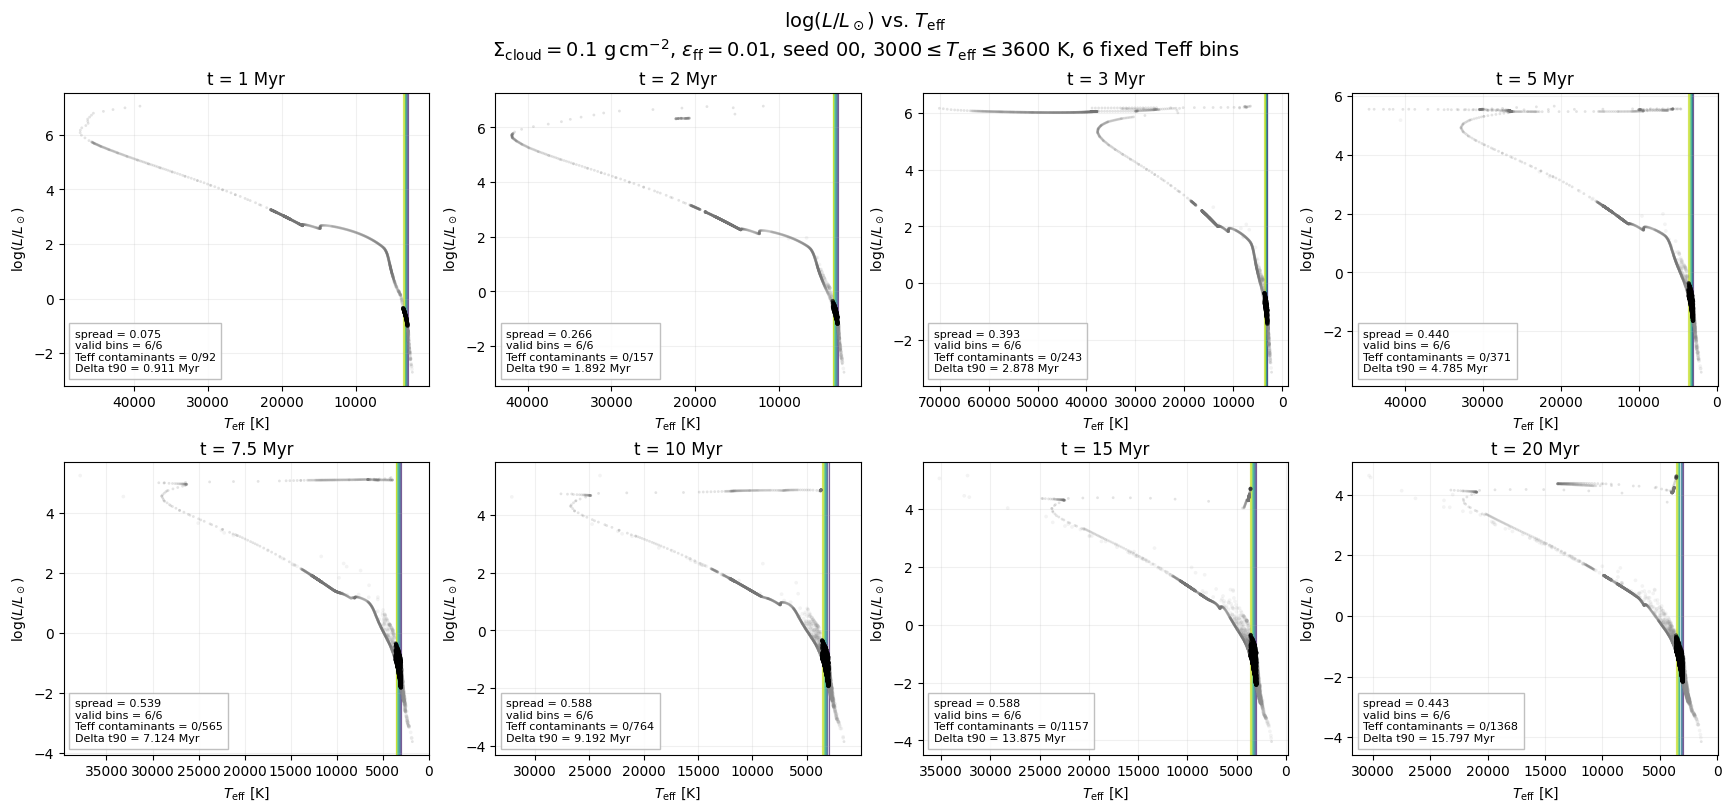

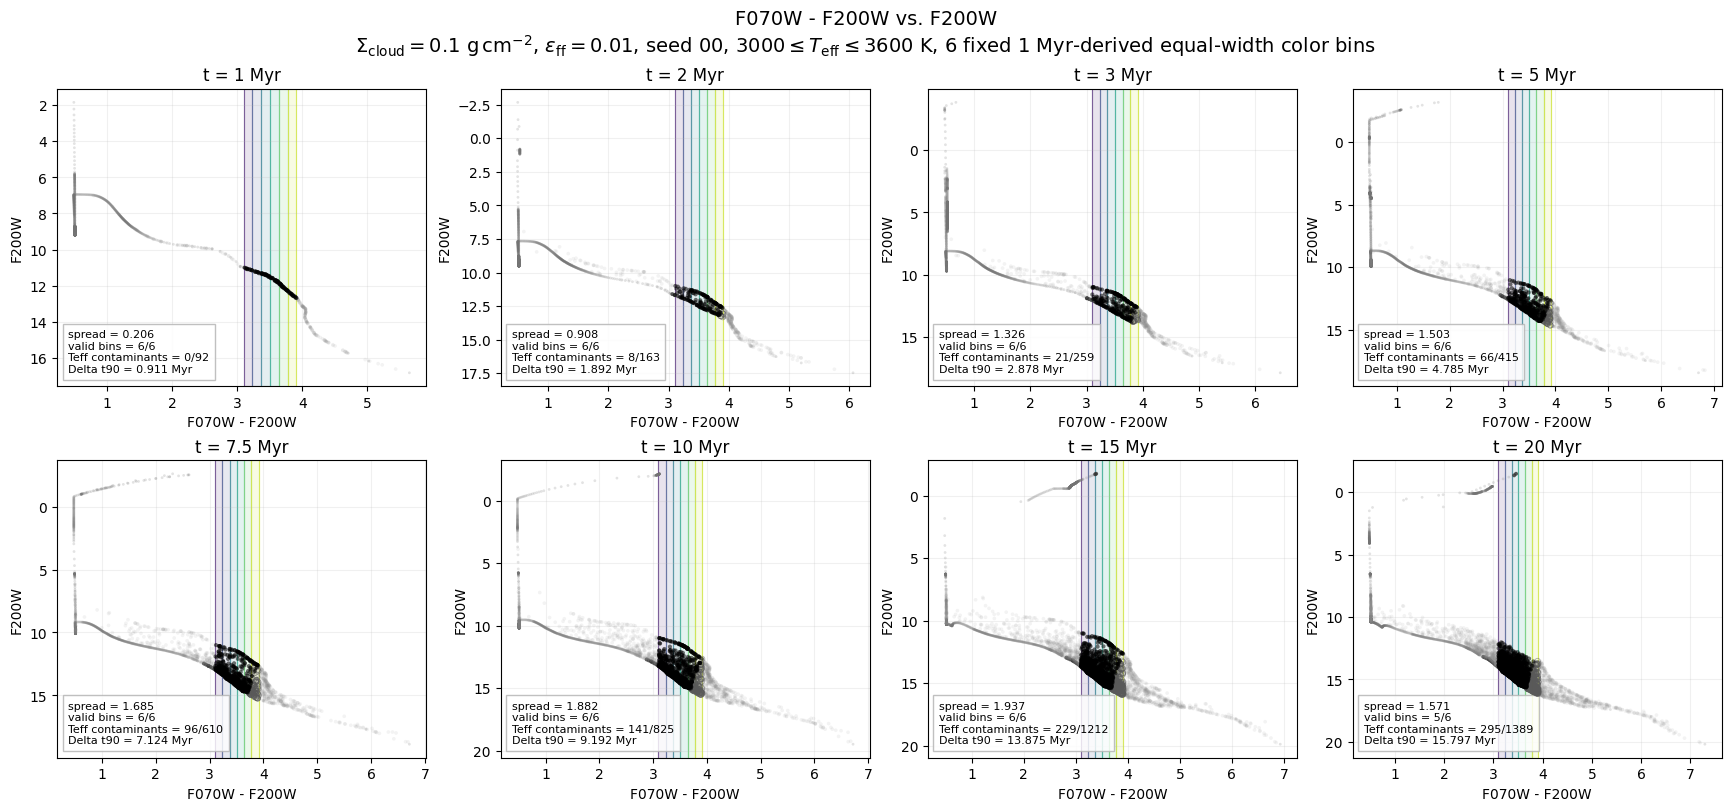

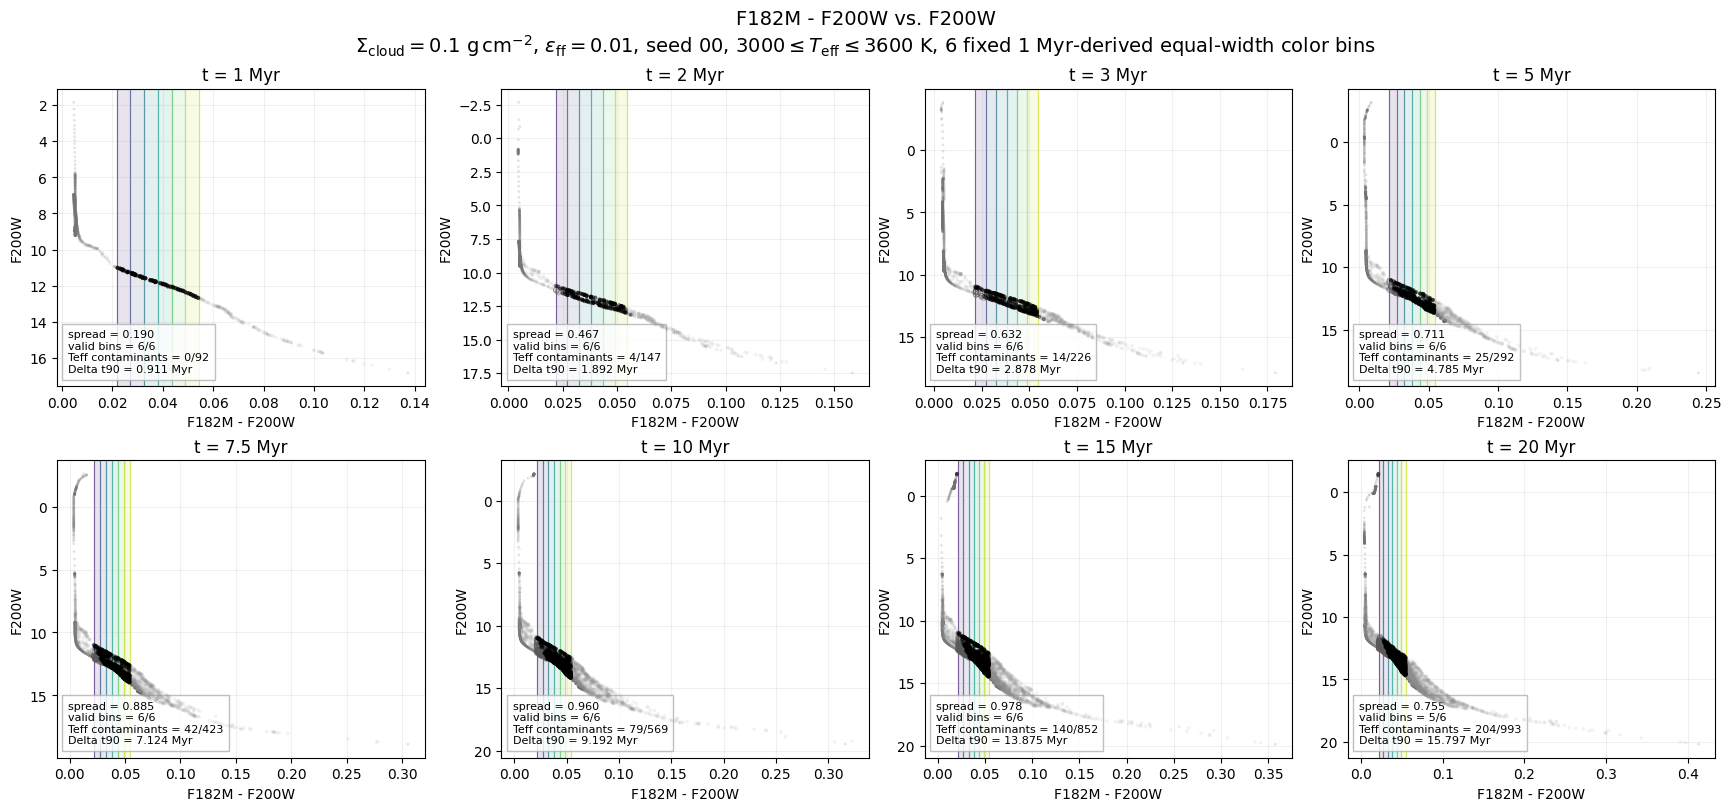

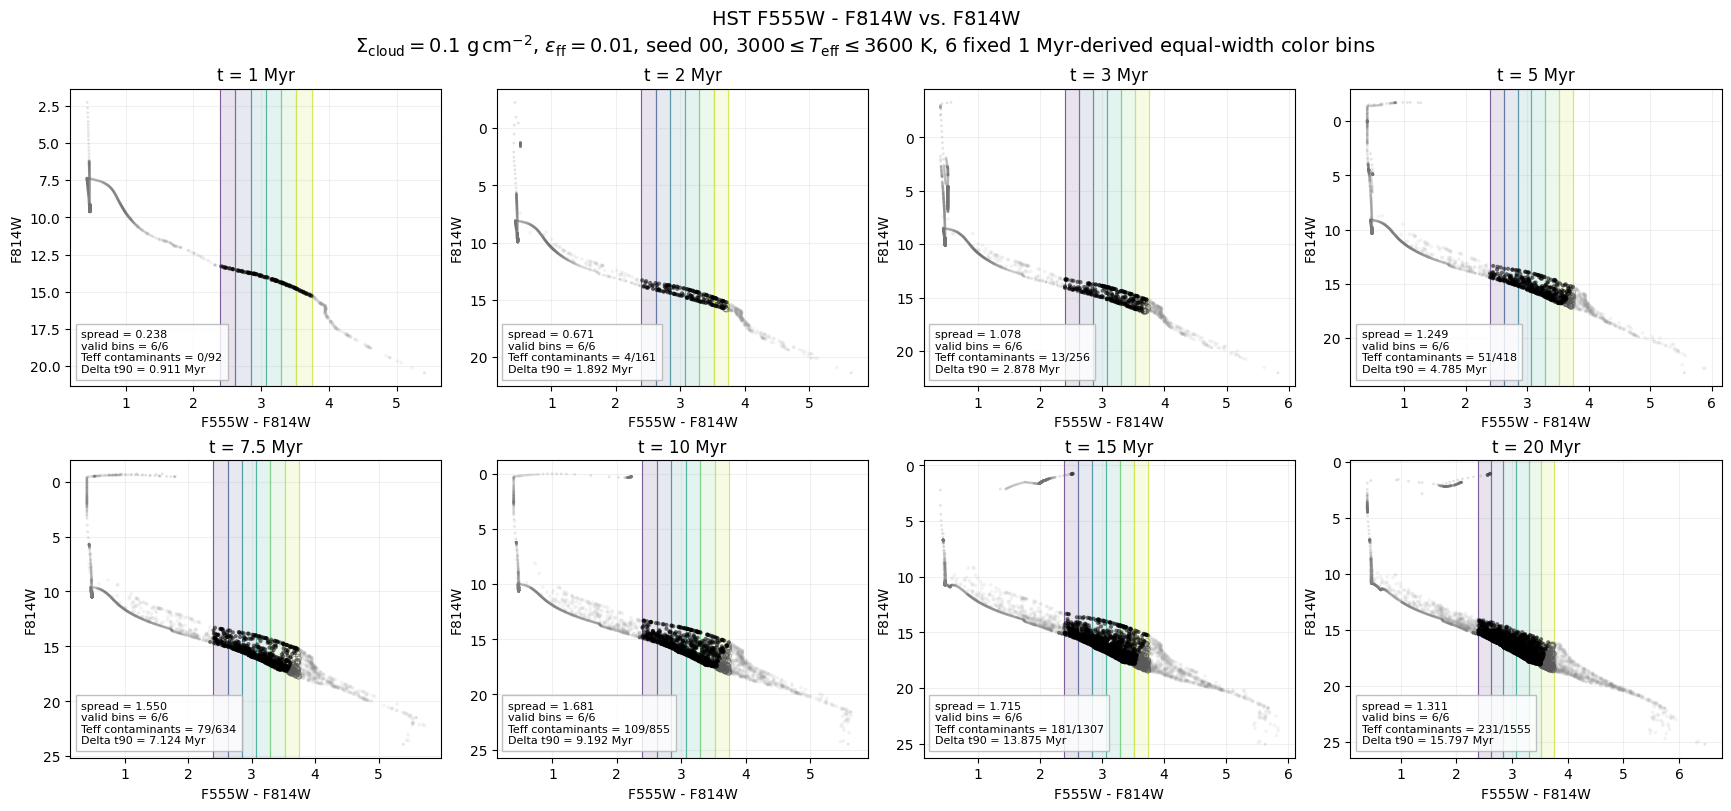

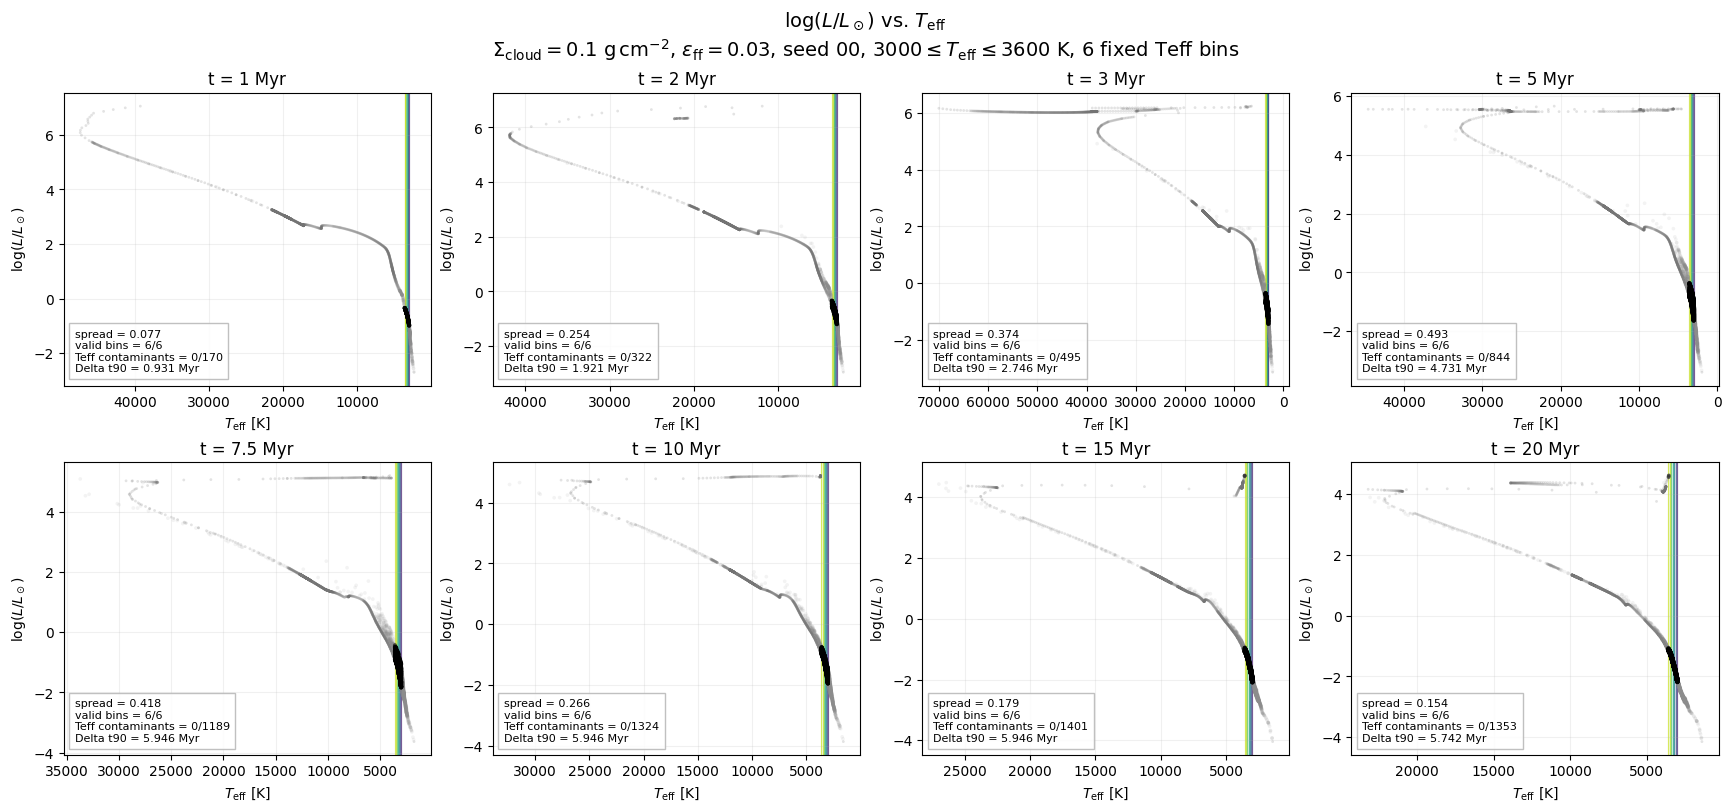

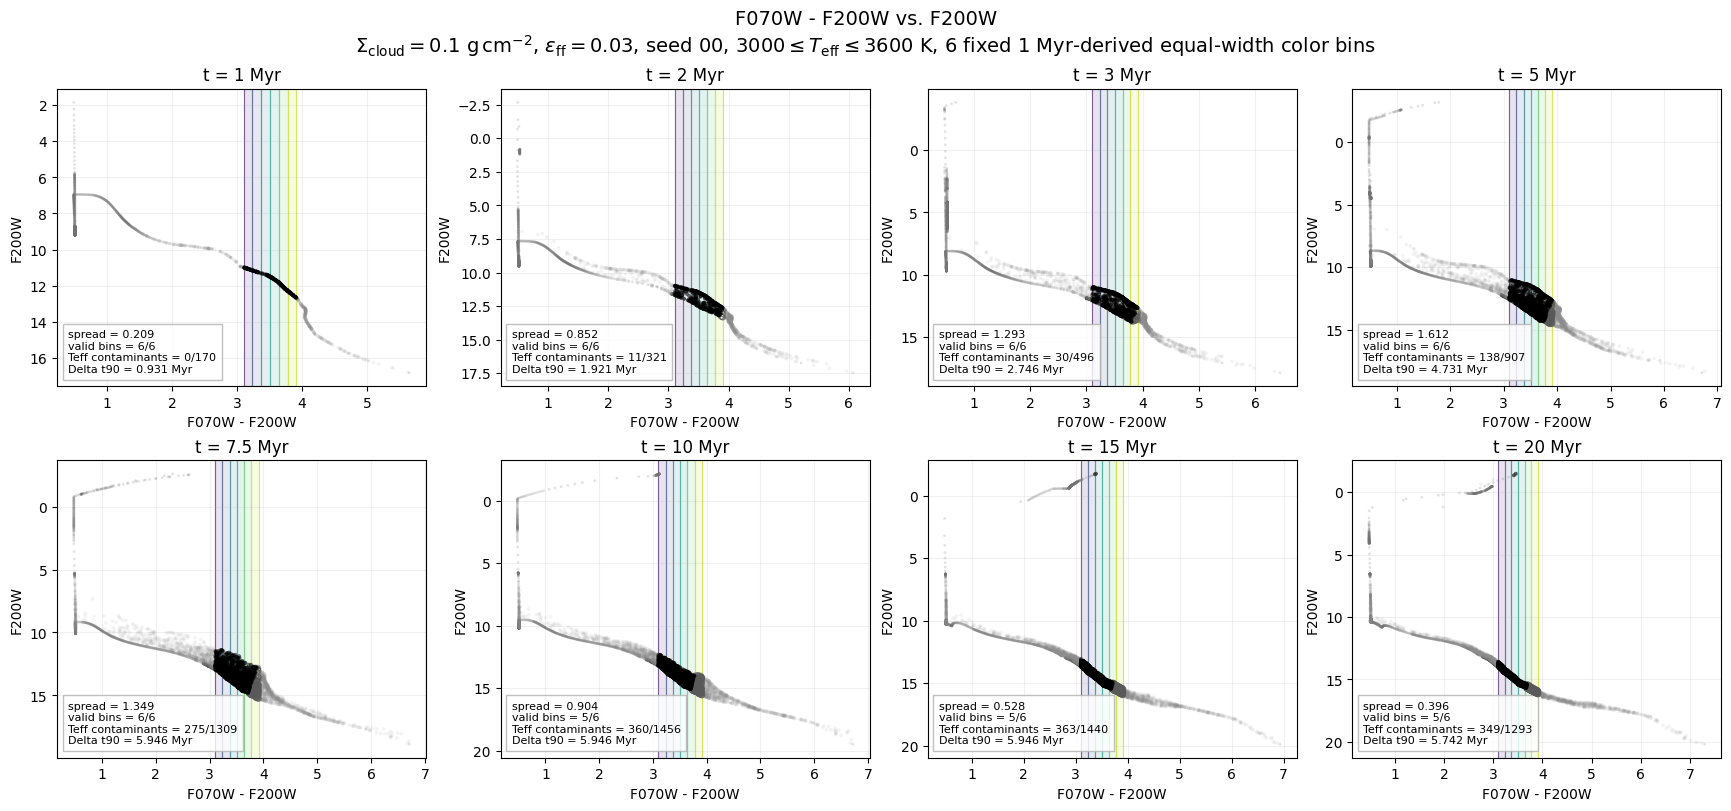

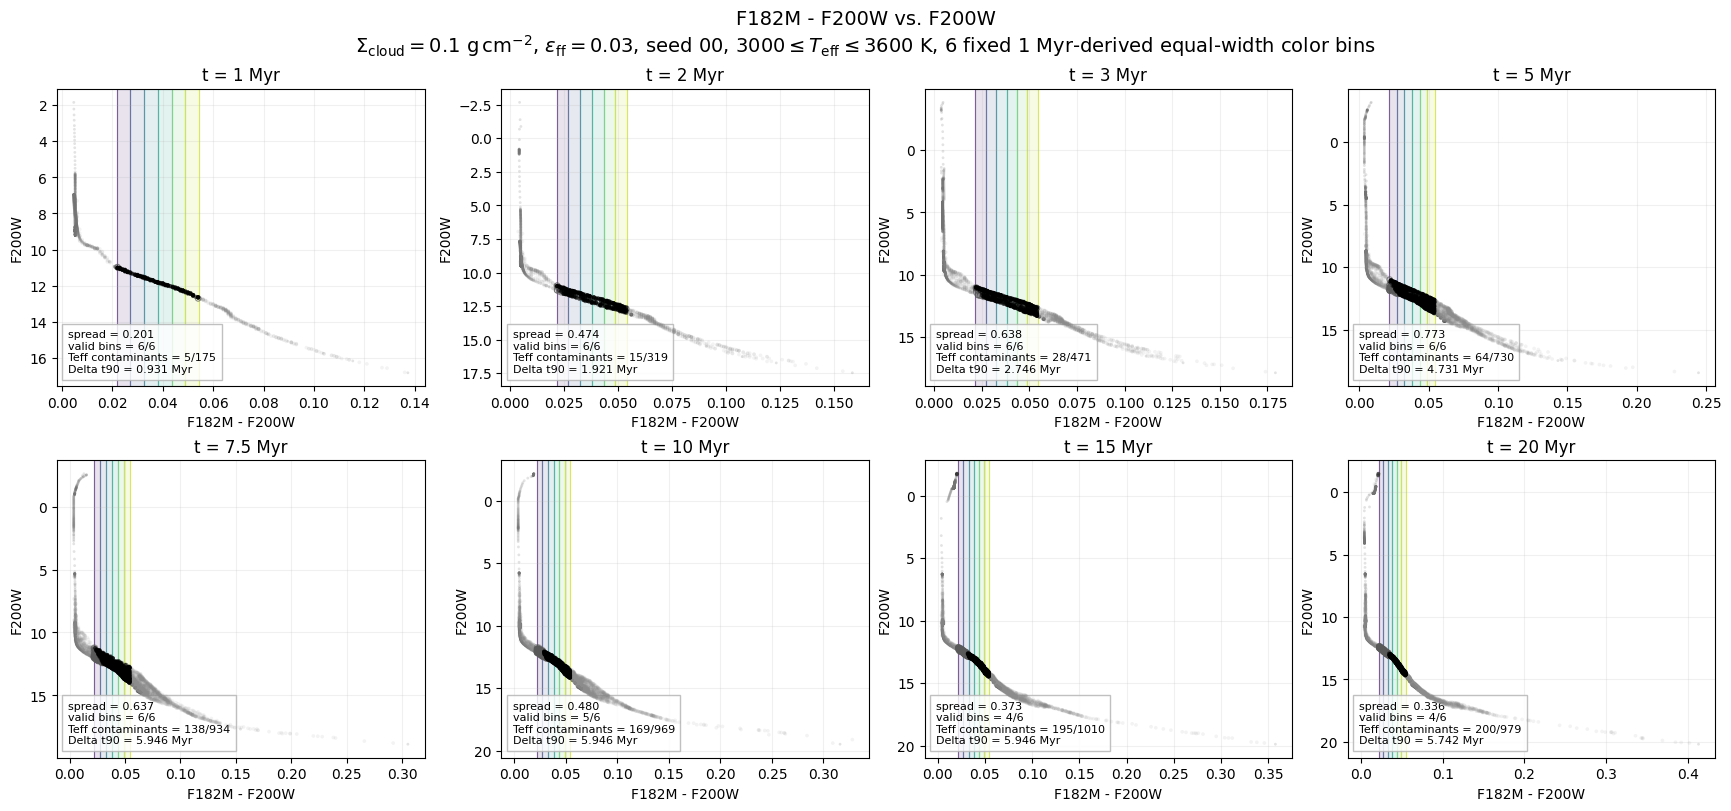

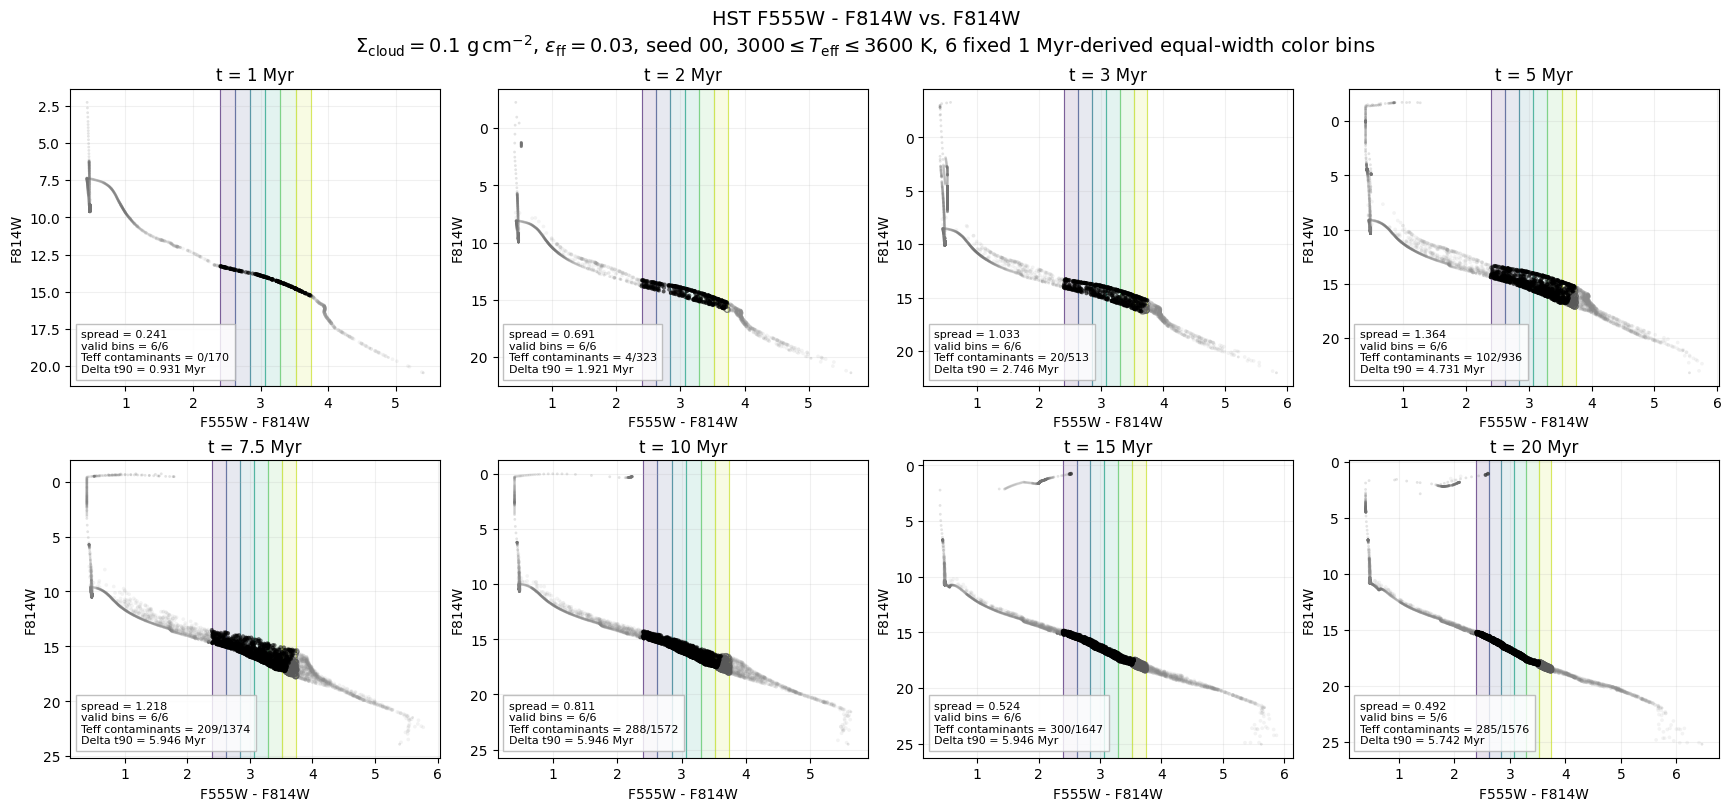

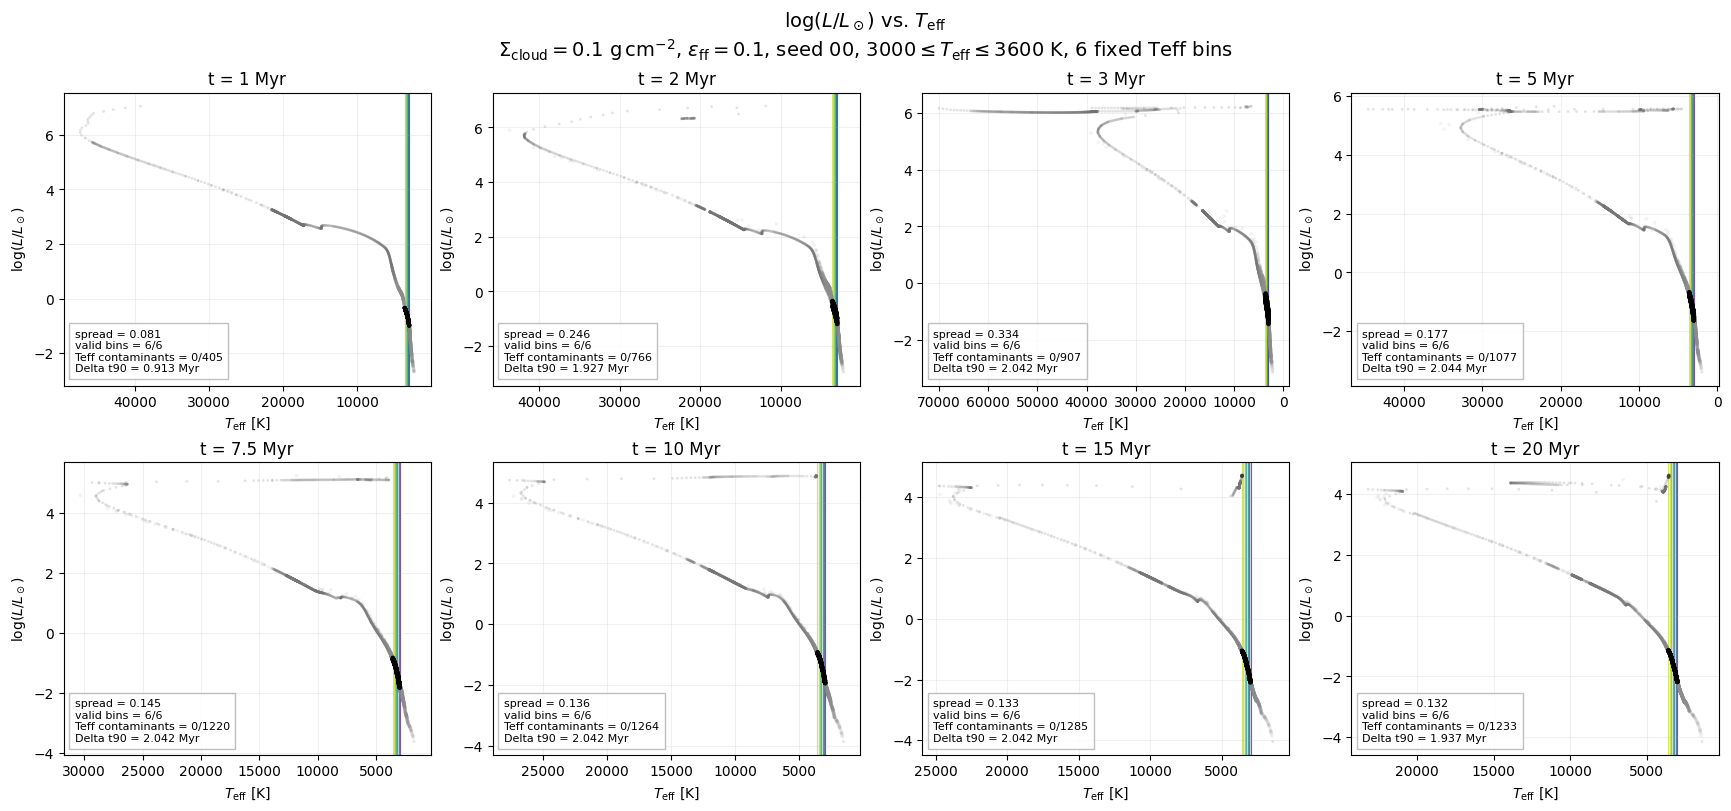

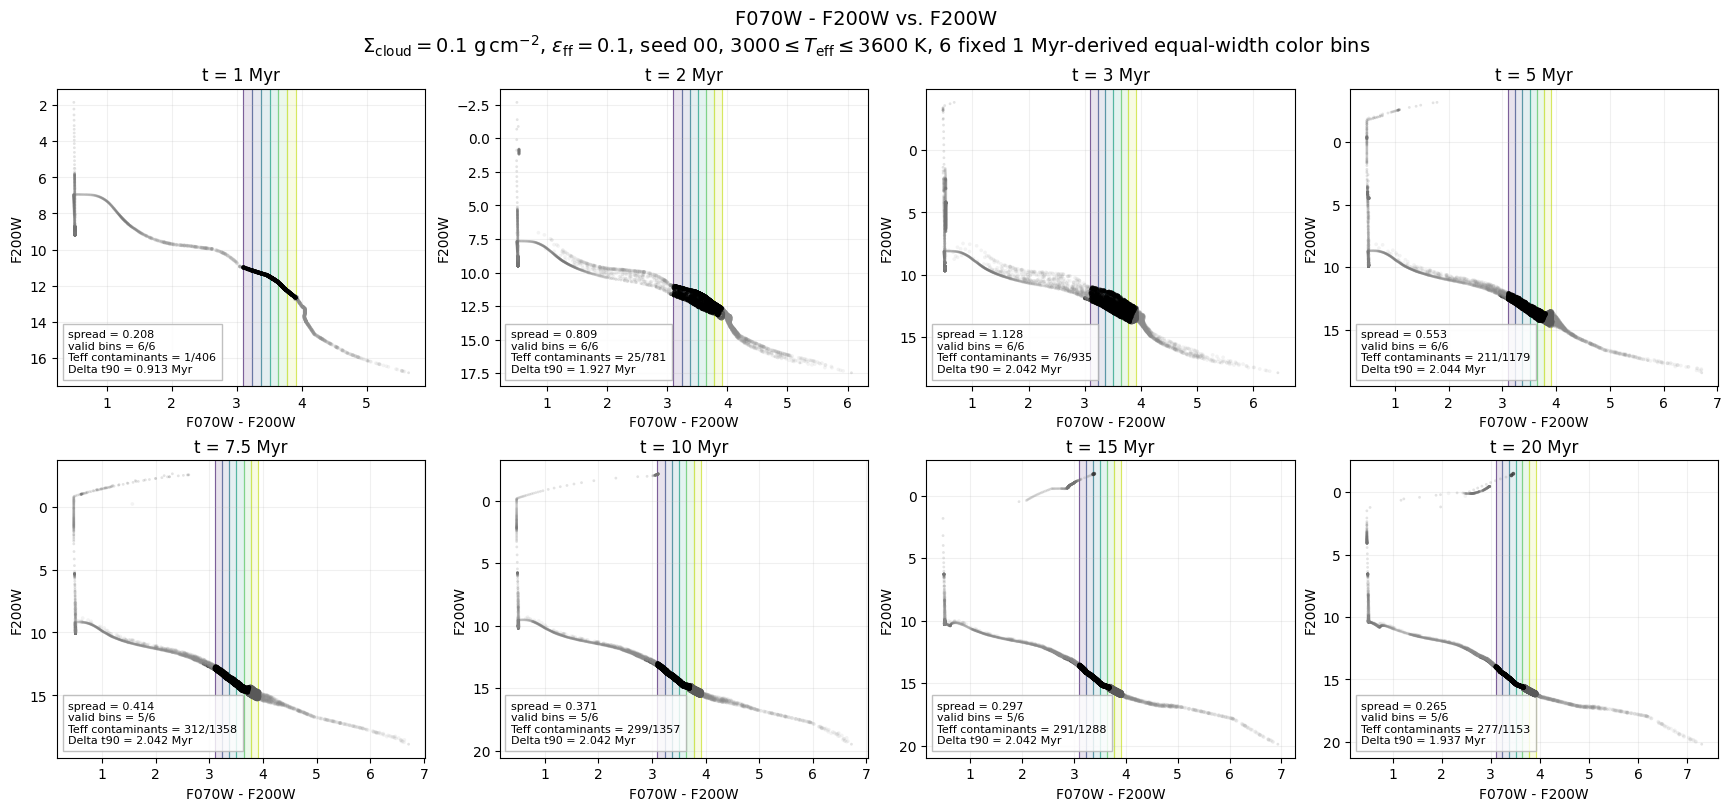

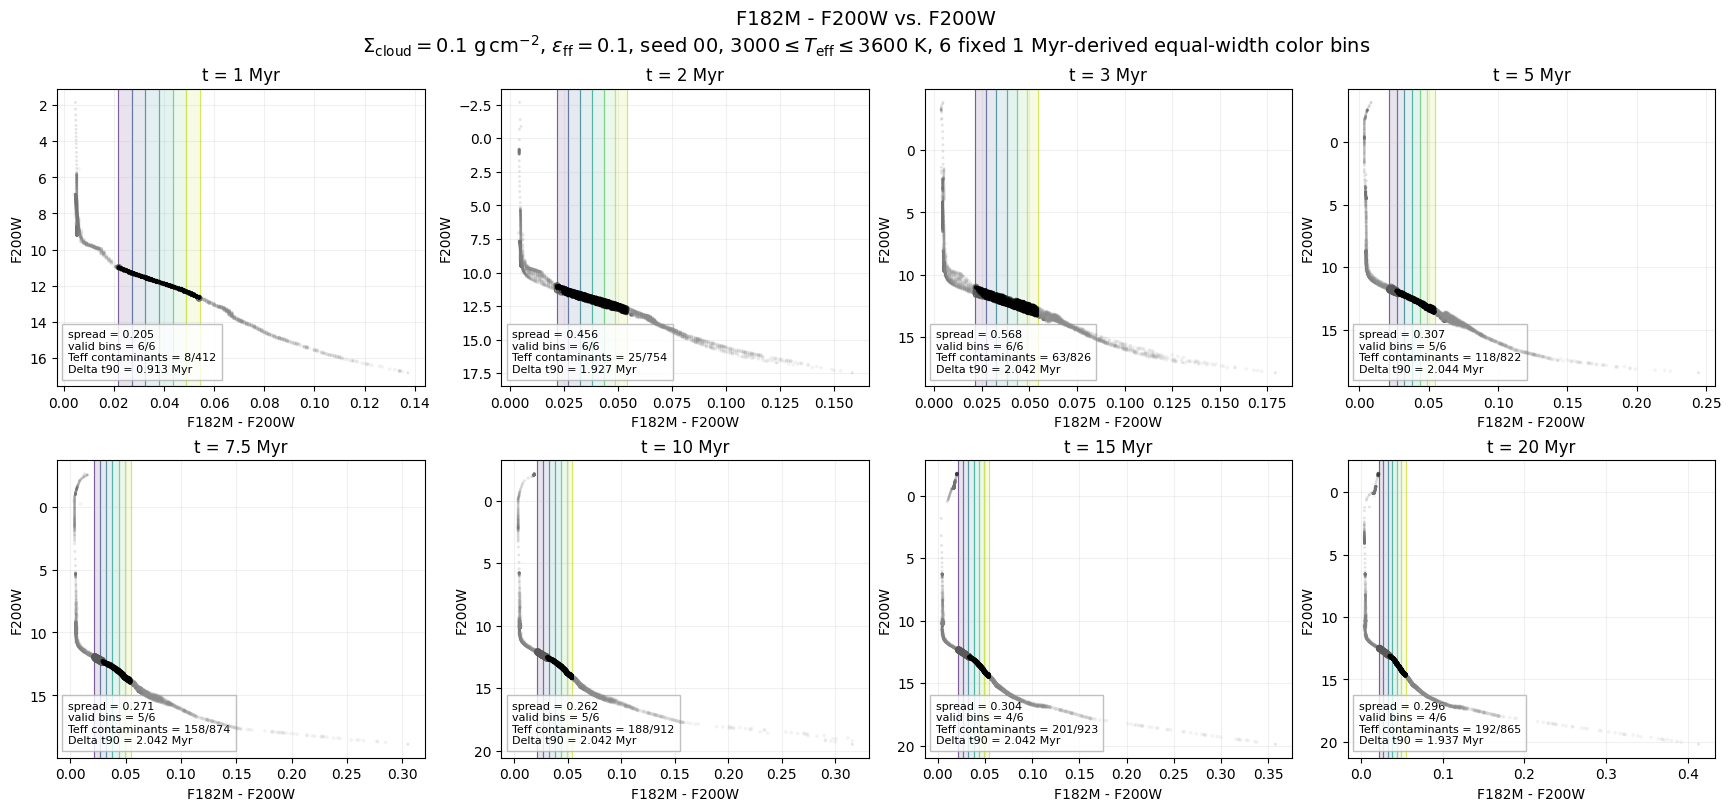

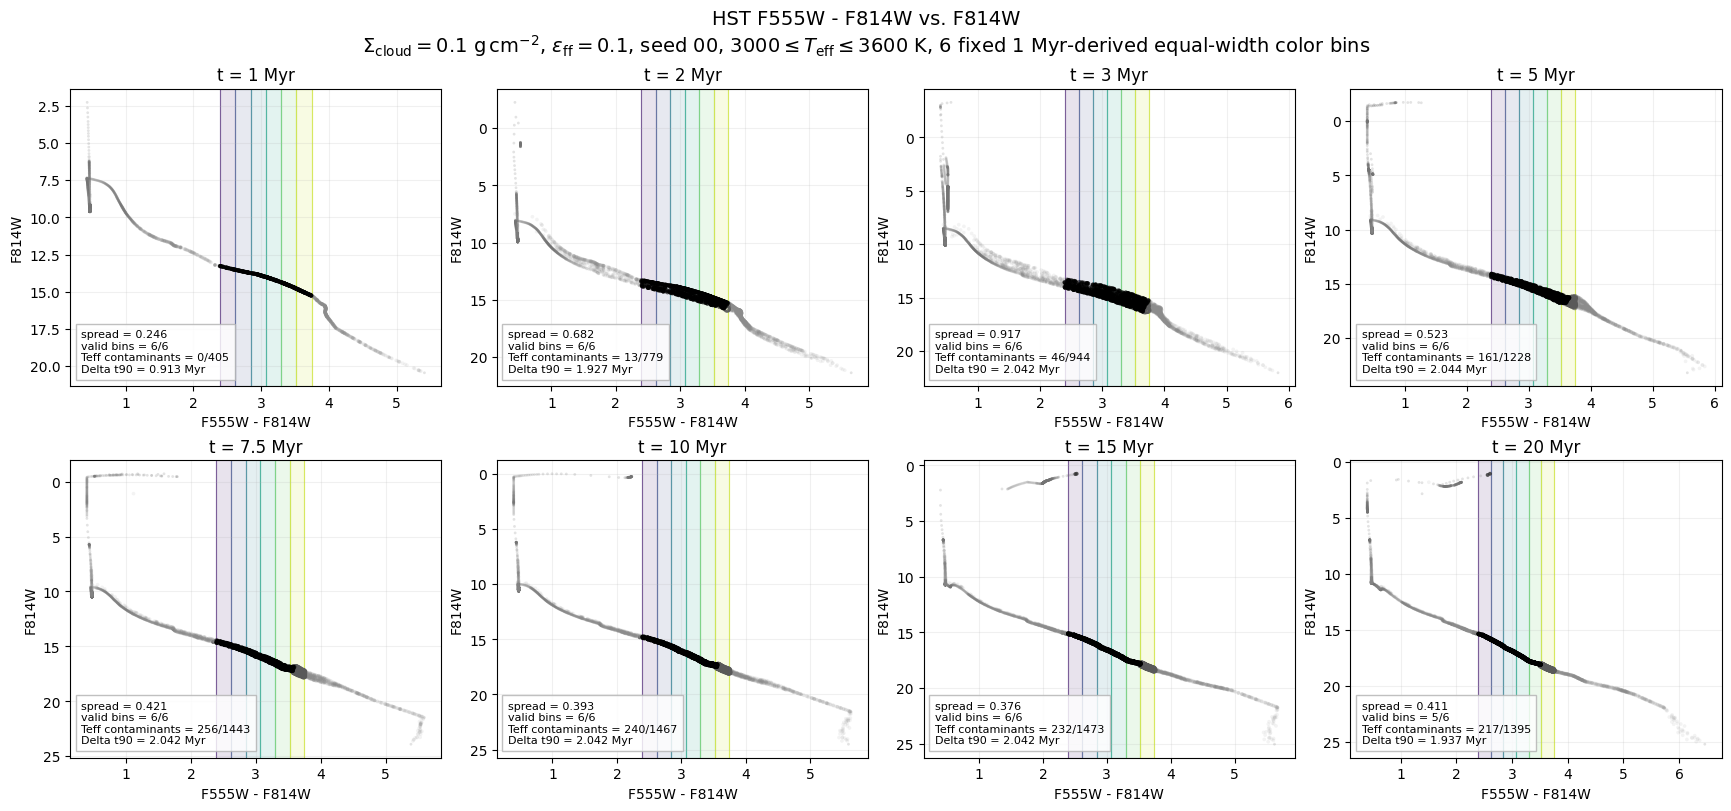

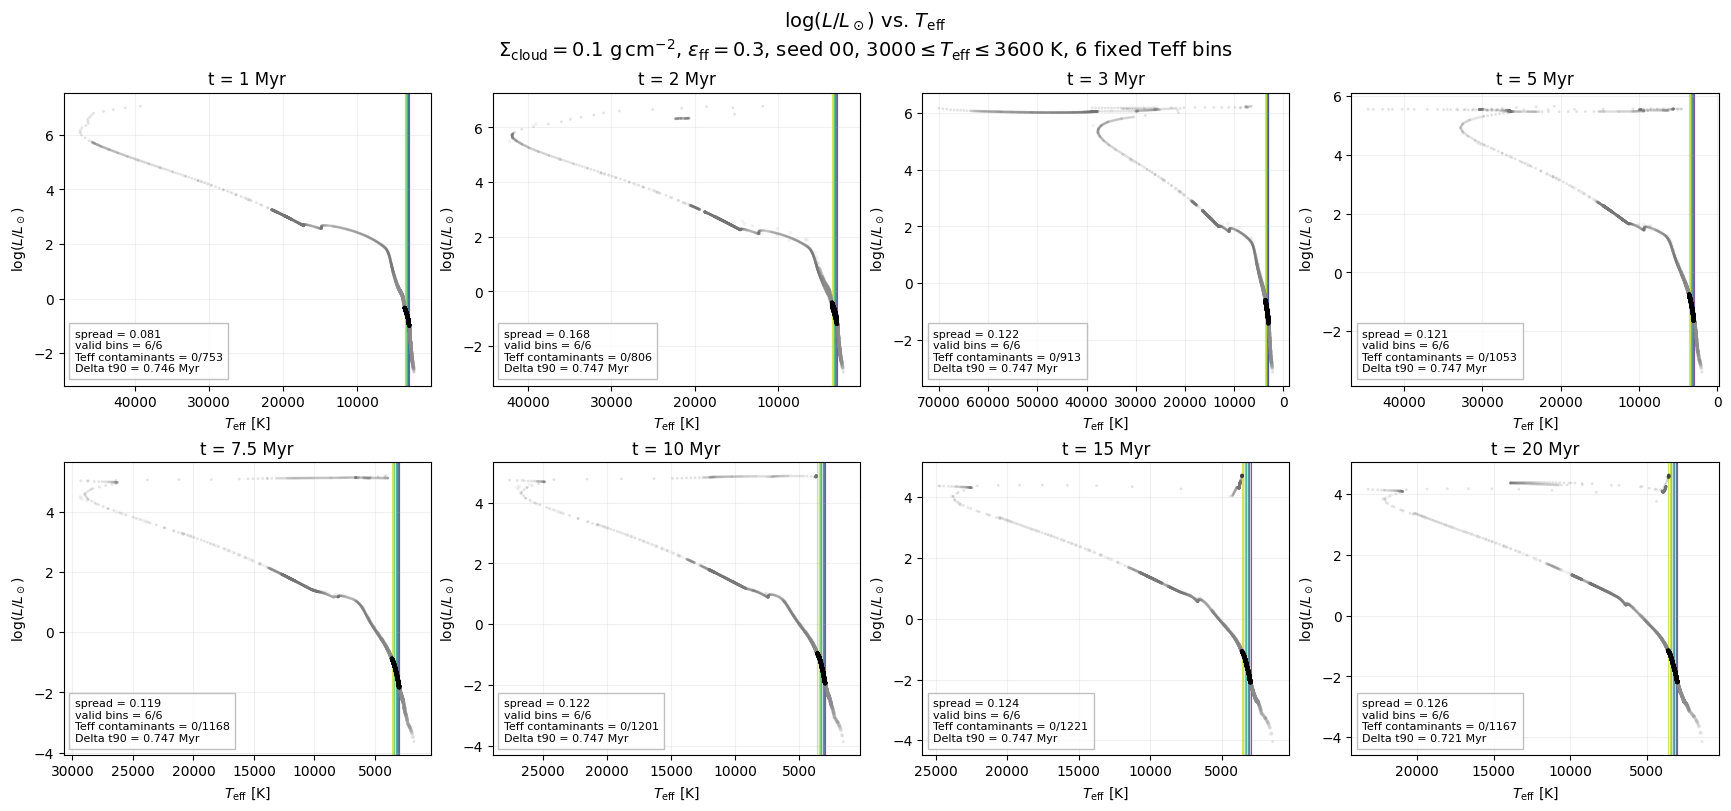

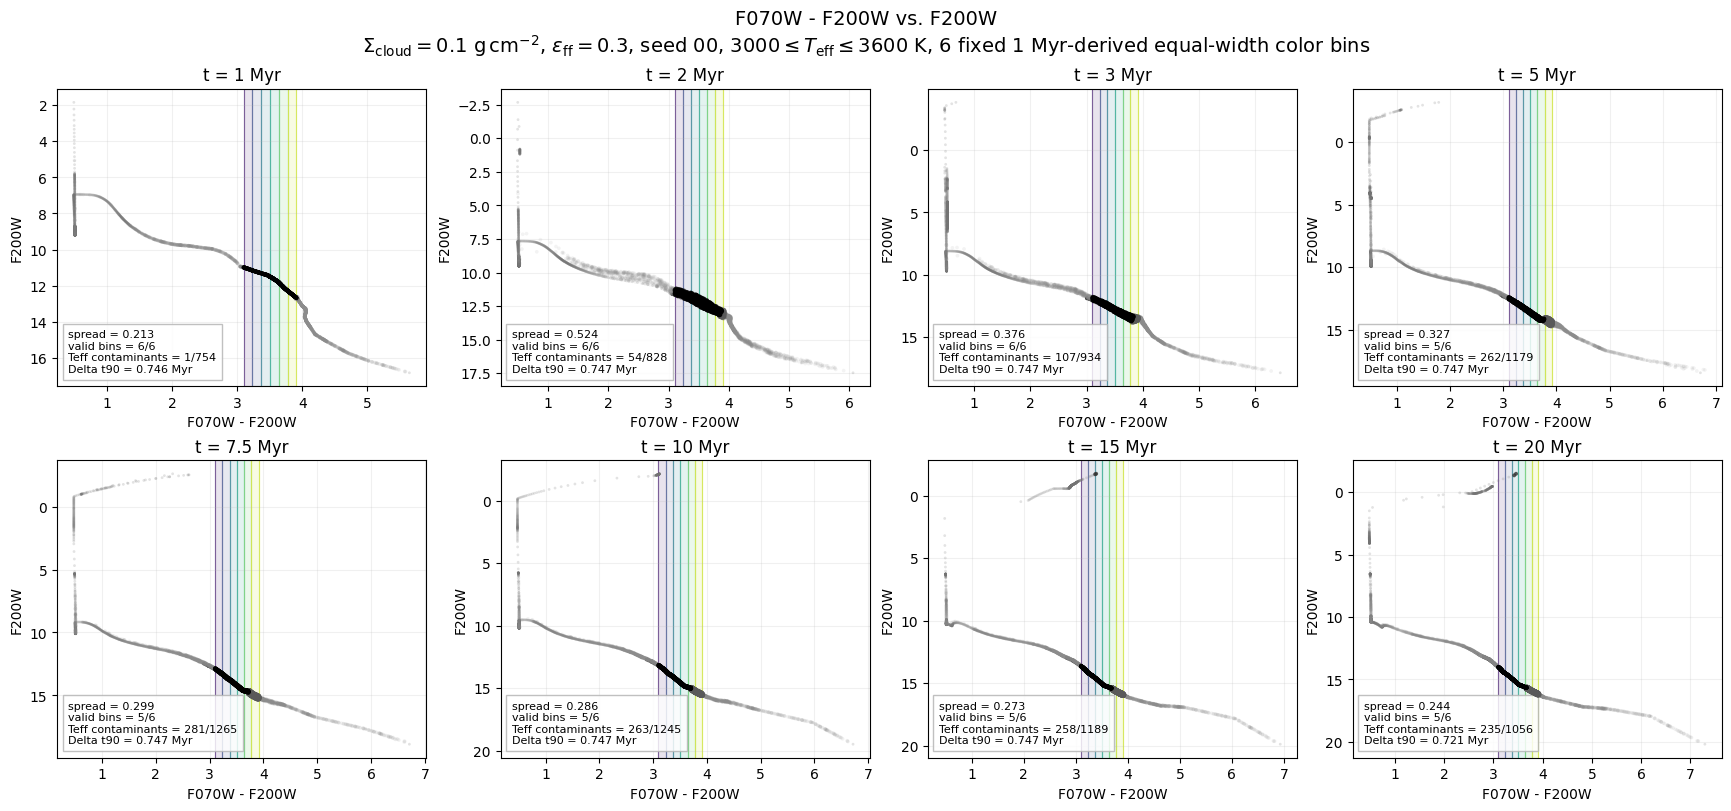

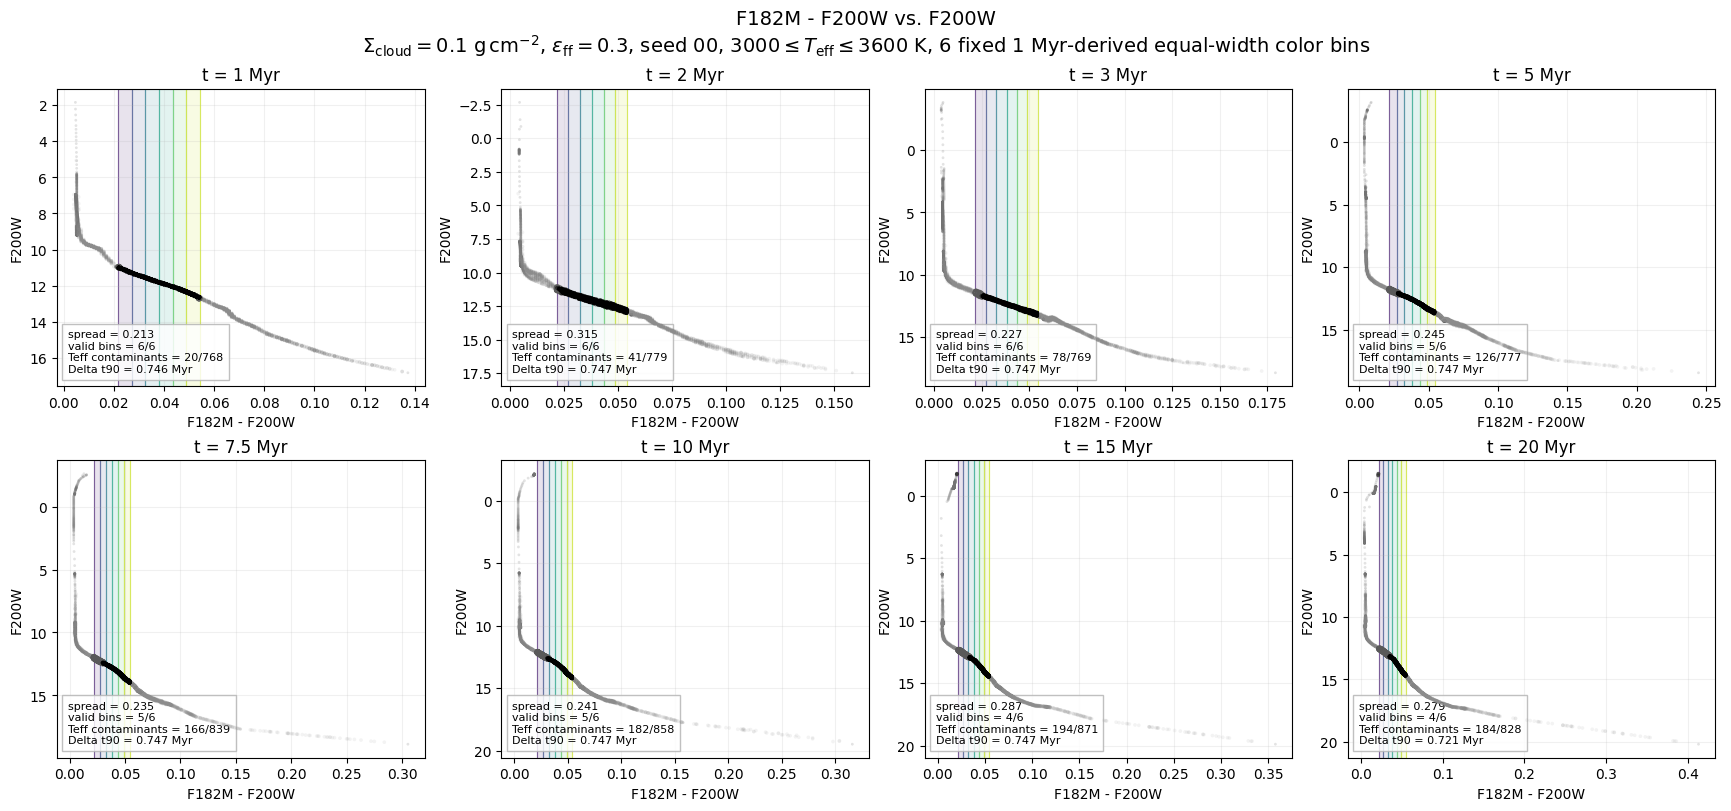

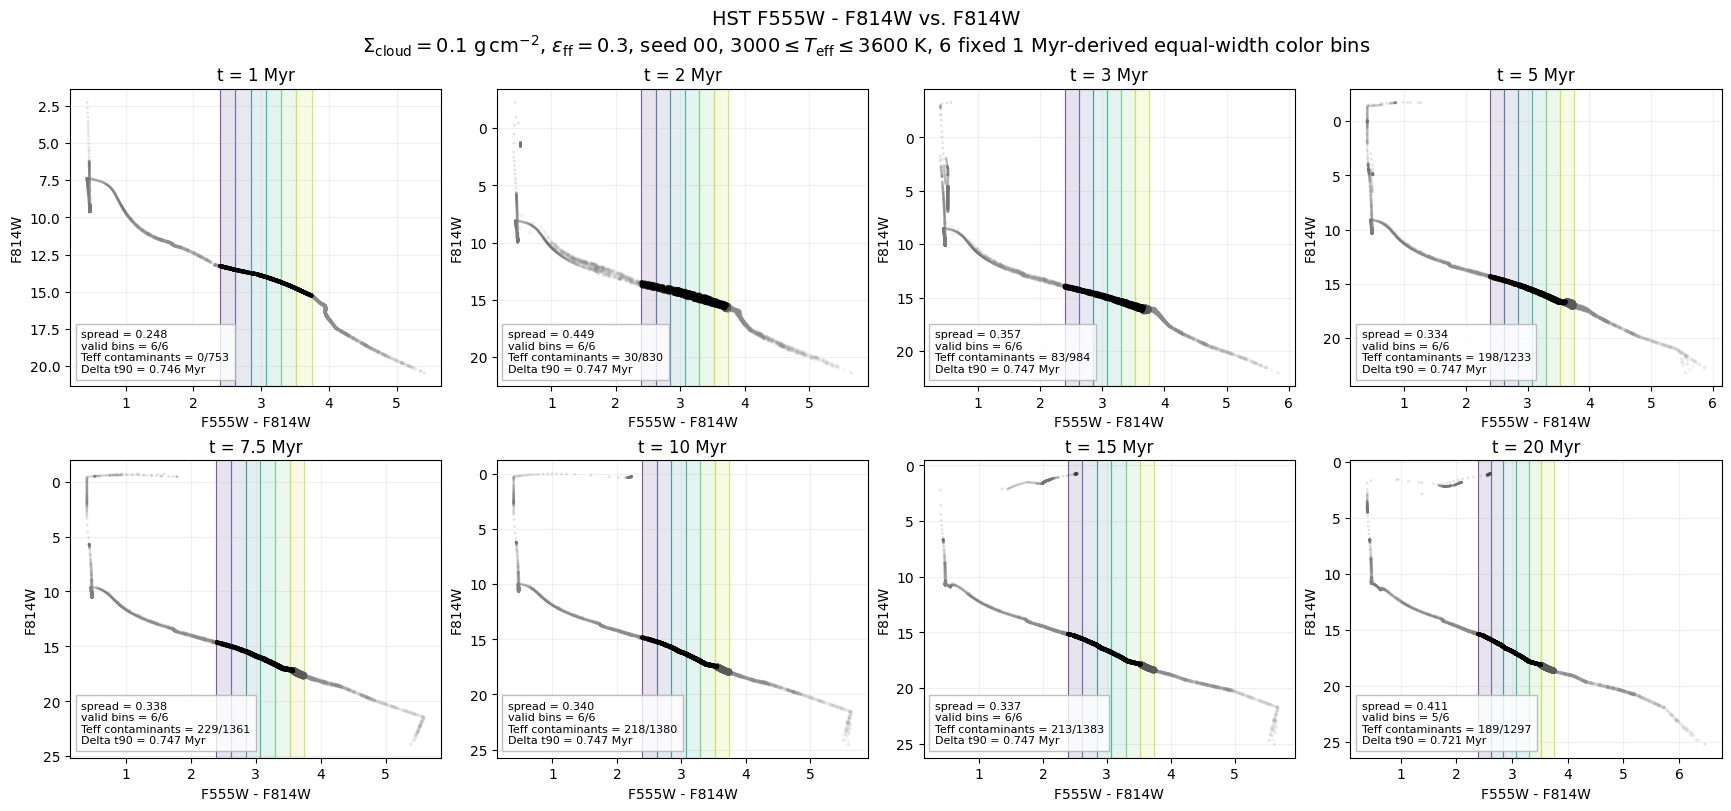

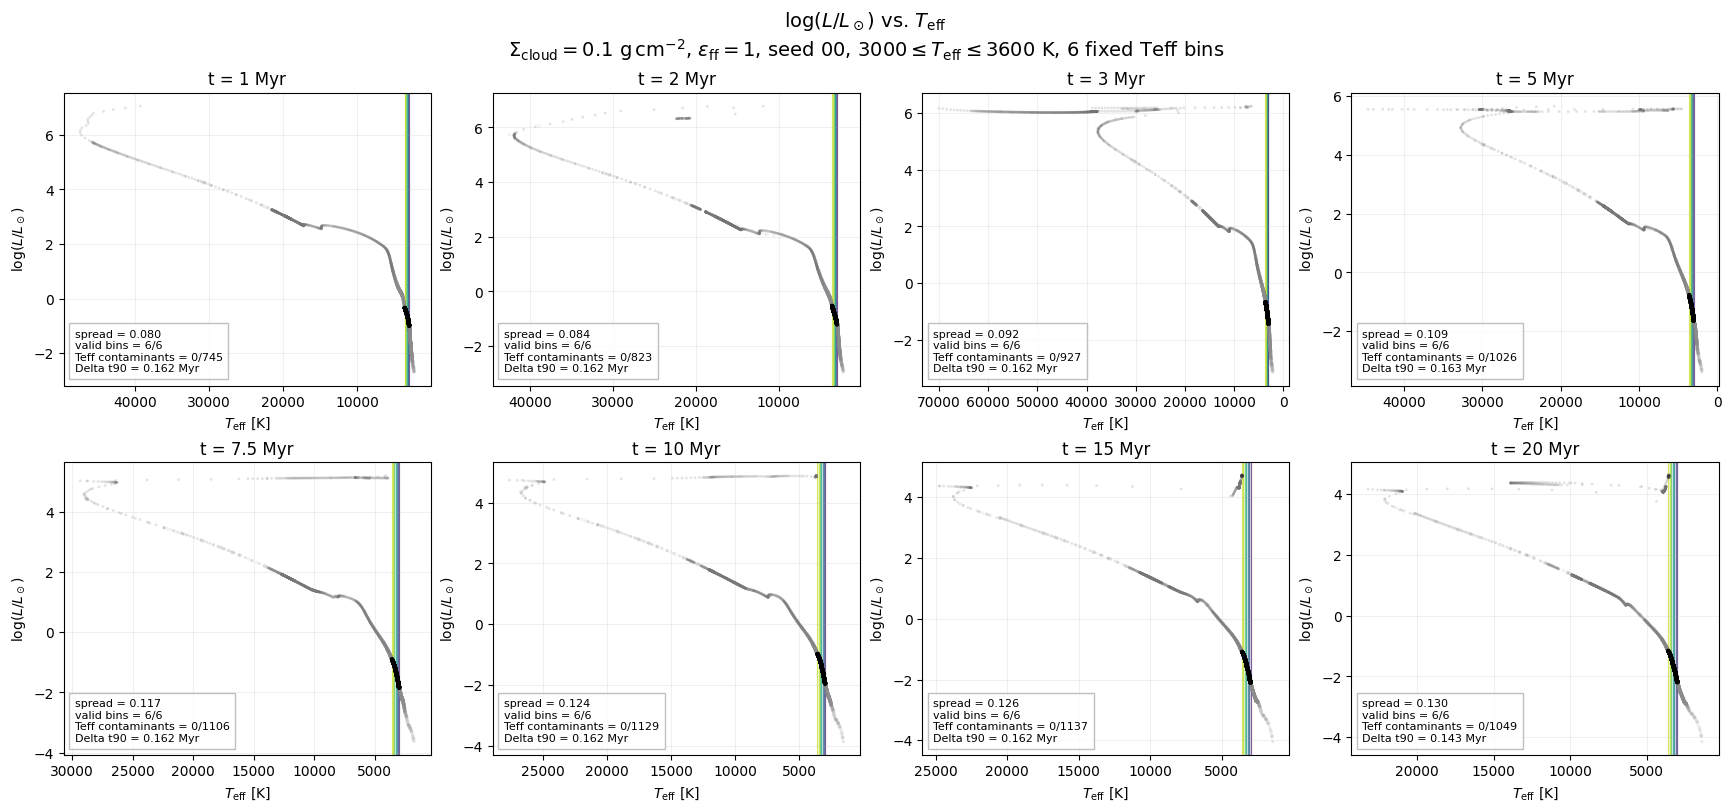

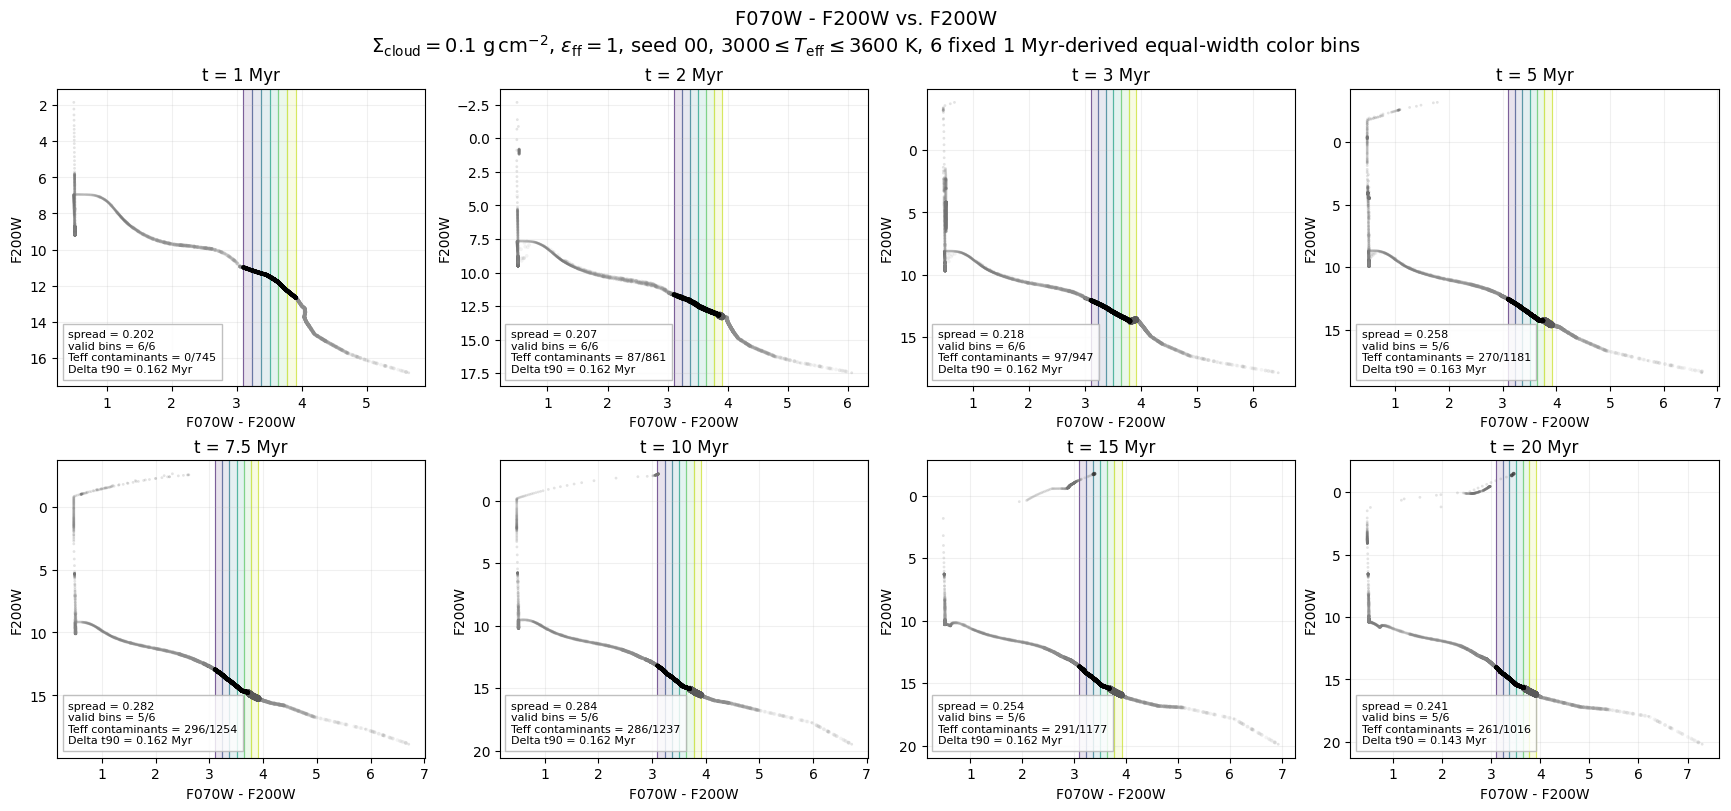

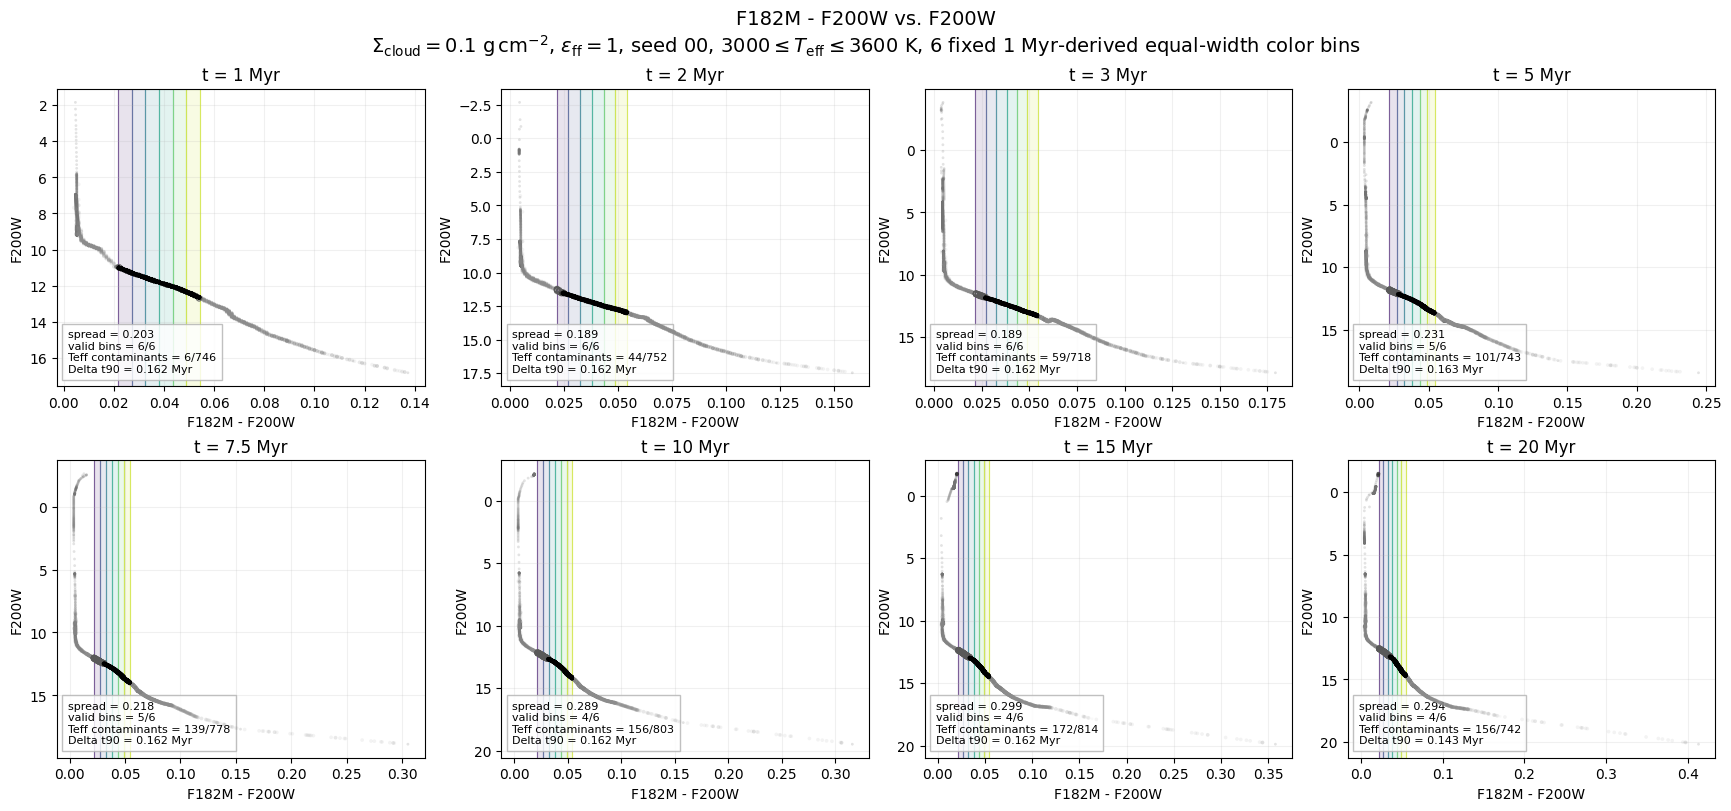

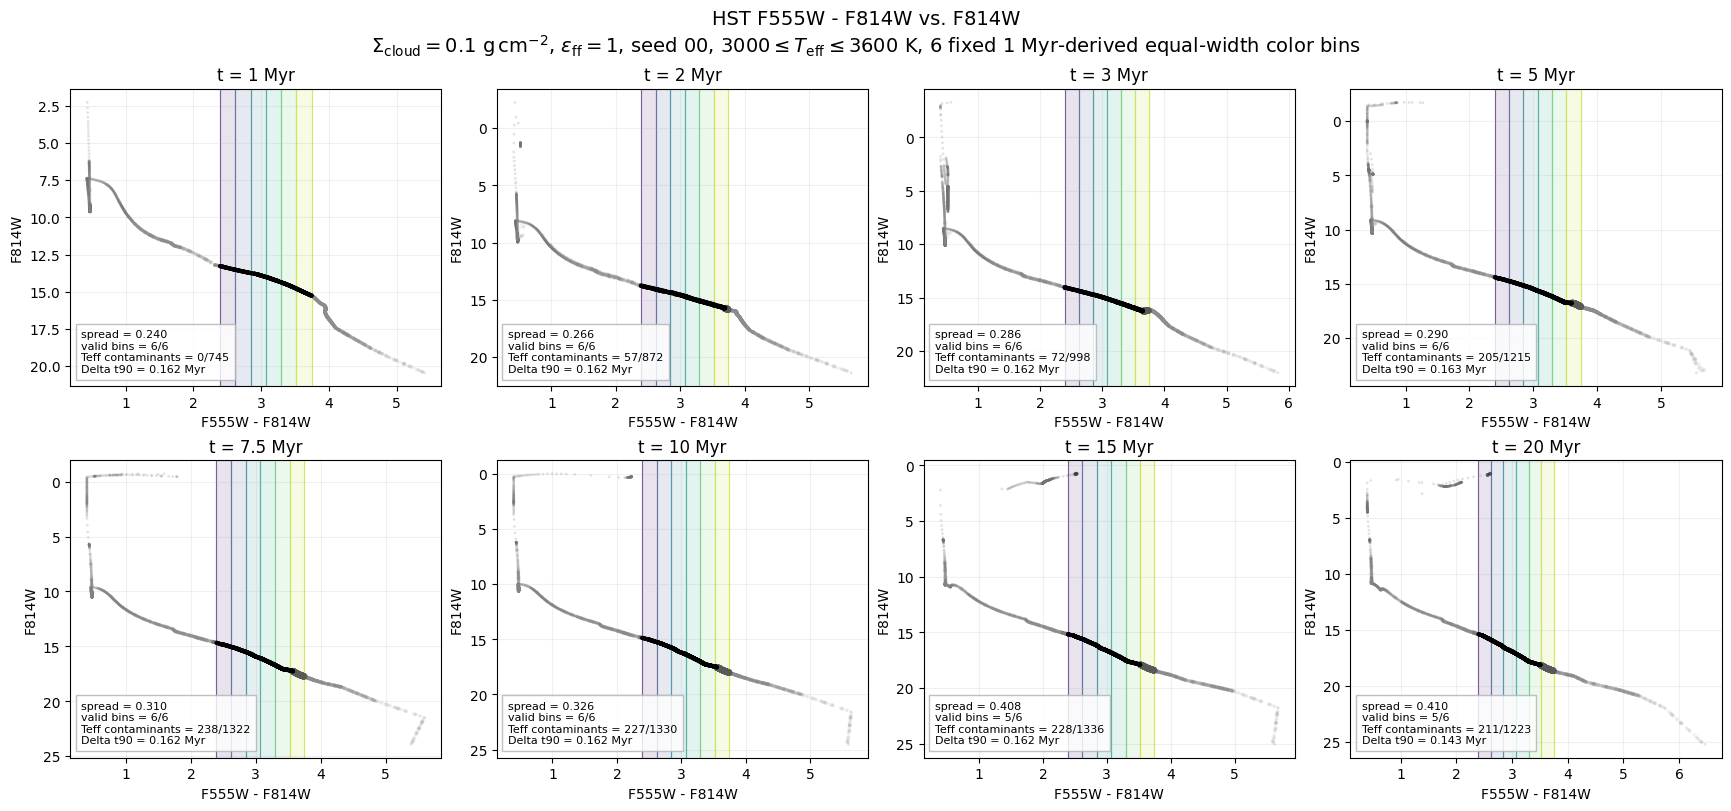

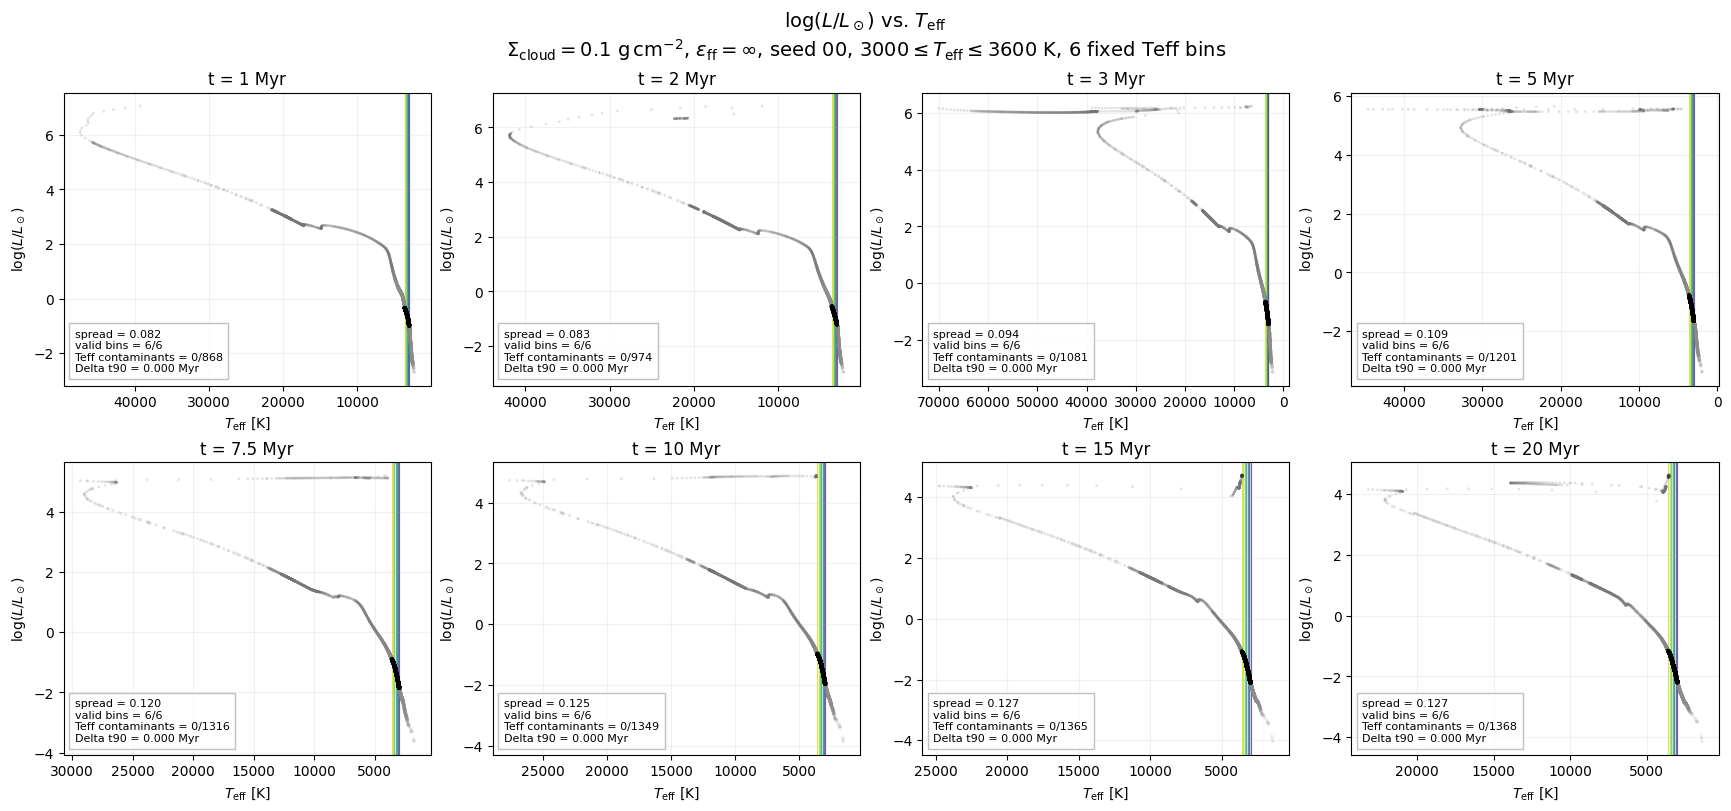

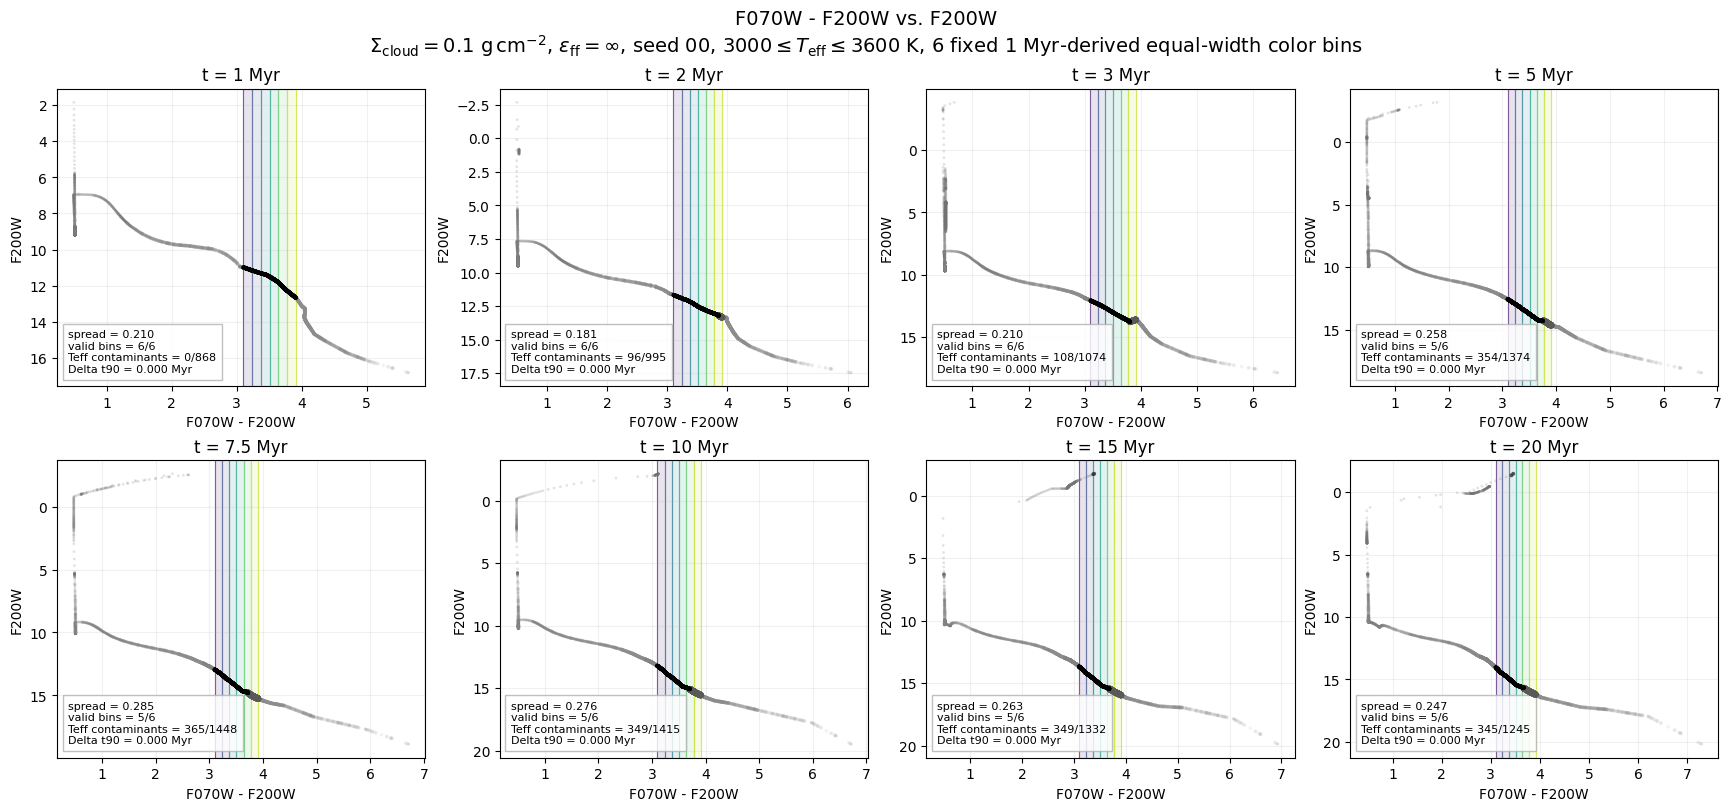

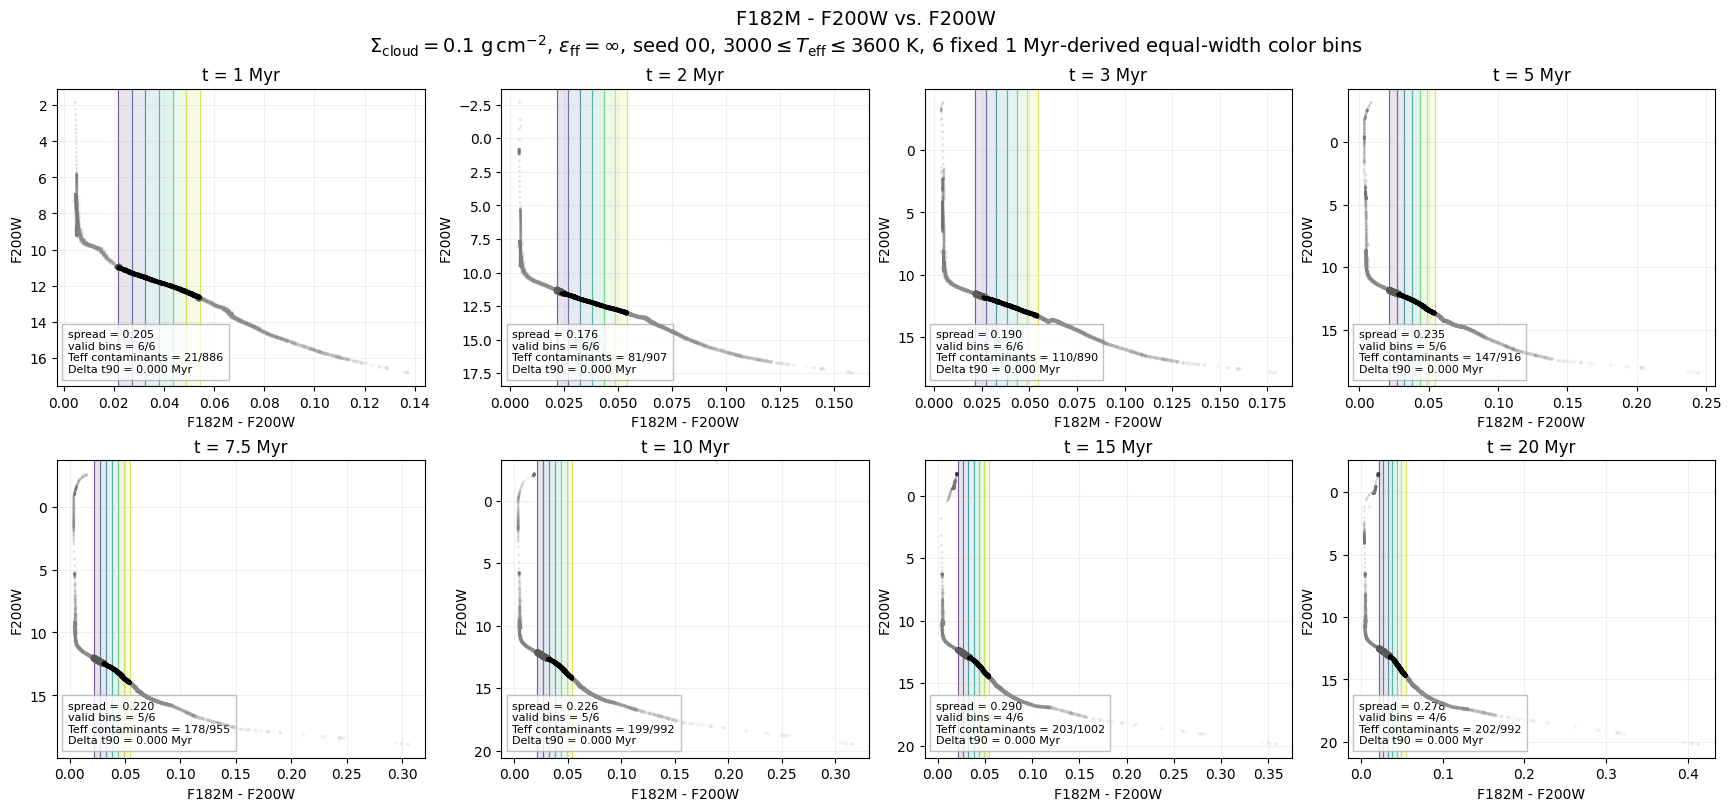

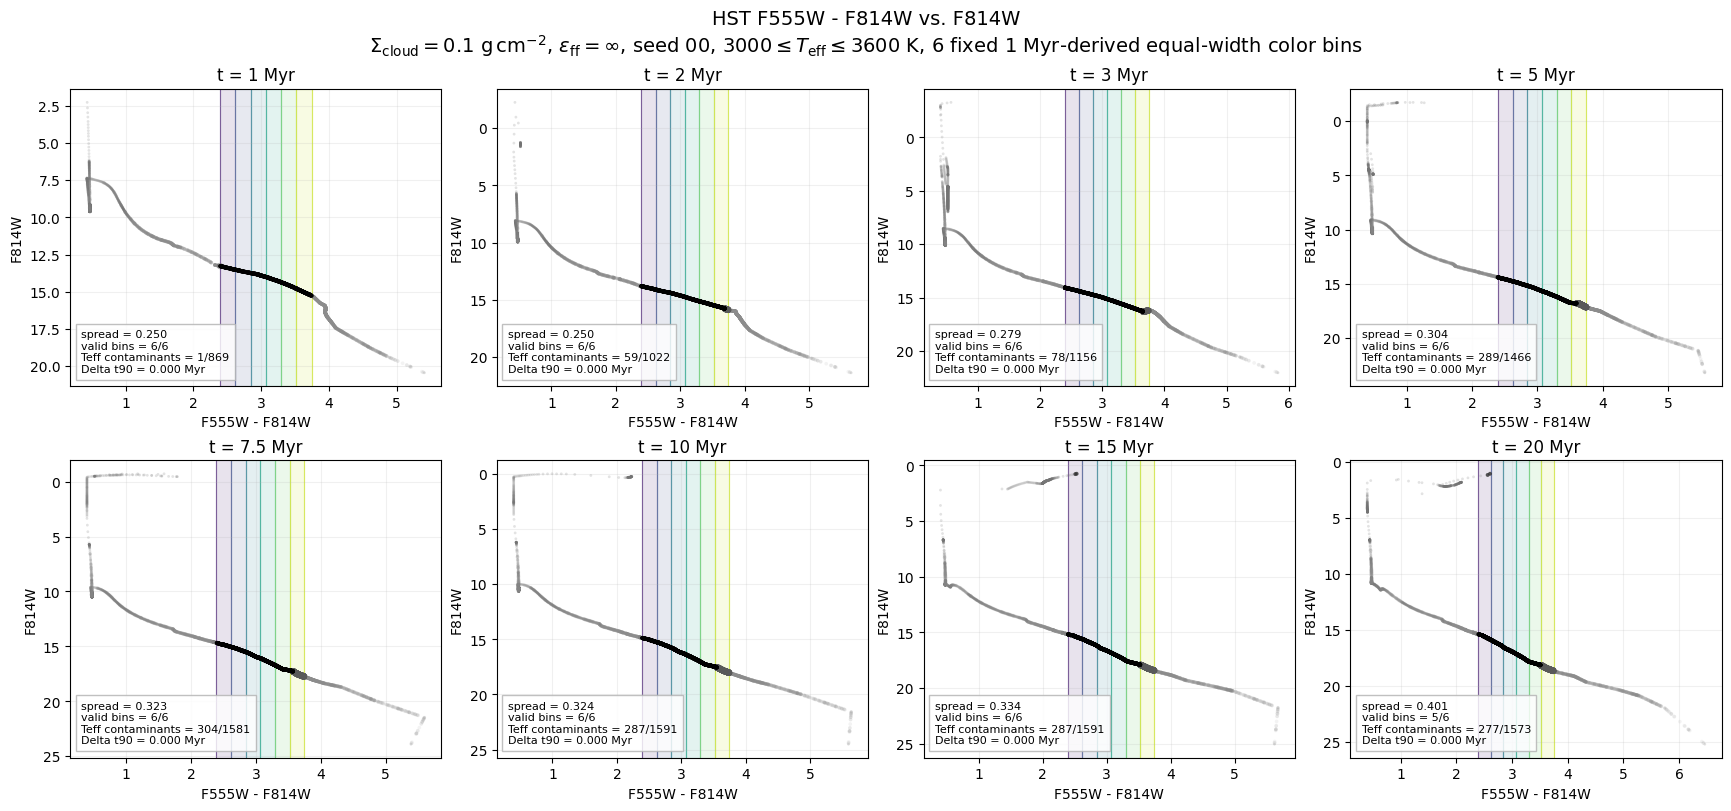

In [20]:
for case in CASE_ORDER:
    for diagram in DIAGRAMS:
        plot_time_evolution(
            case,
            diagram,
        )

## Raw spread comparison: all finite epsilon_ff values + instantaneous

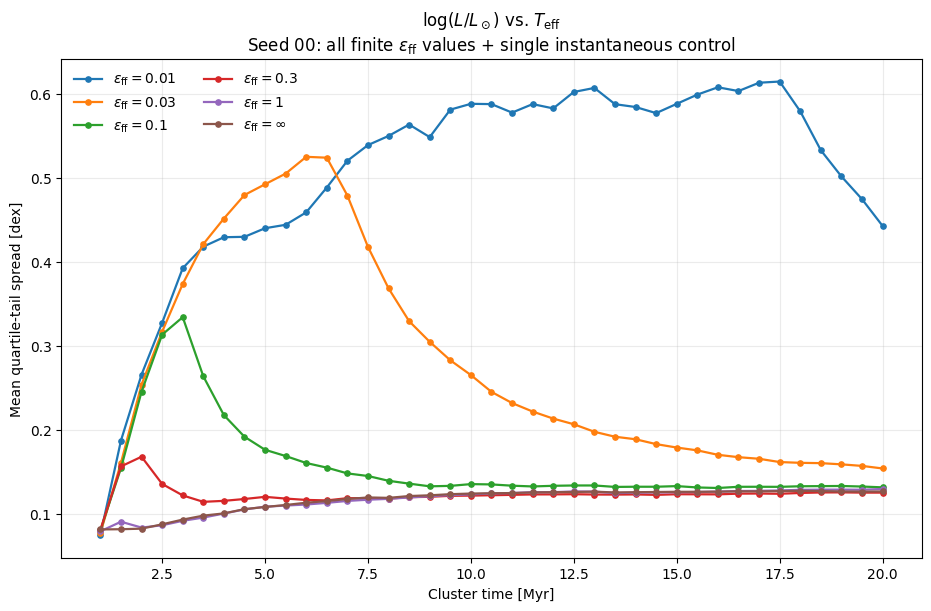

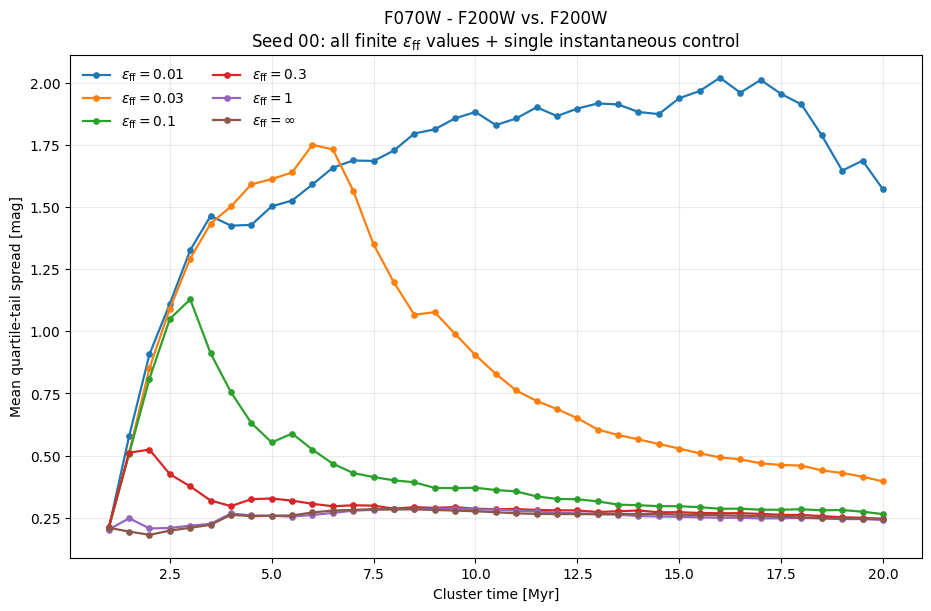

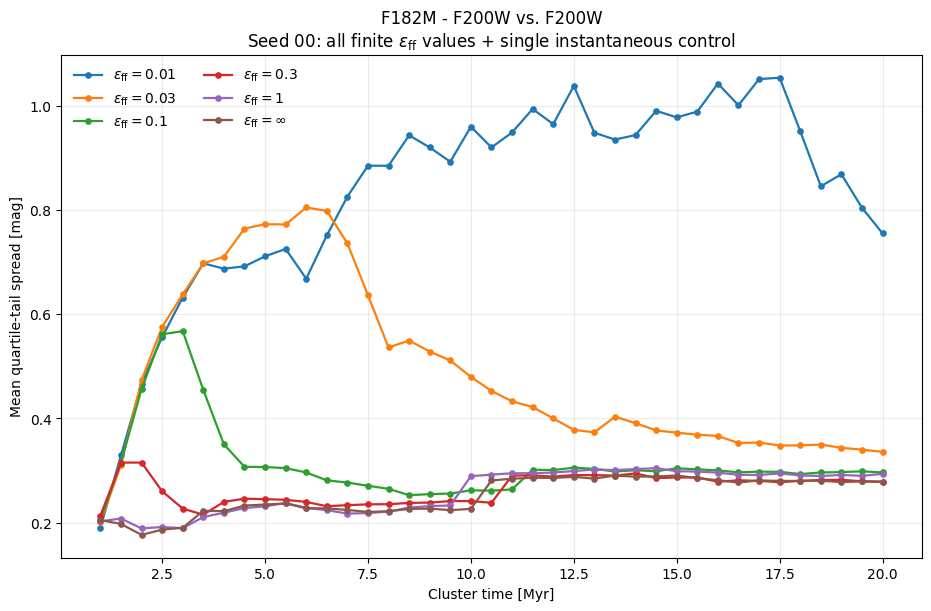

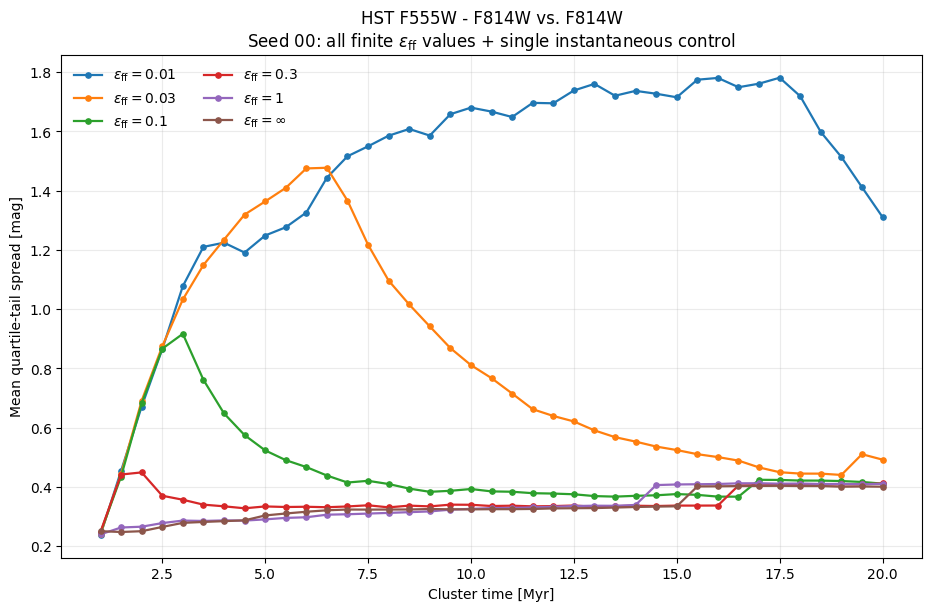

In [21]:
for diagram in DIAGRAMS:
    fig, ax = plt.subplots(figsize=(9.2, 6.0), constrained_layout=True)
    for case in CASE_ORDER:
        sub = (
            df_metrics[
                (df_metrics['case'] == case)
                & (df_metrics['diagram'] == diagram.key)
            ]
            .sort_values('snapshot_time_myr')
        )
        ax.plot(
            sub['snapshot_time_myr'],
            sub['spread_metric'],
            marker='o', ms=3.8, lw=1.6,
            label=CASE_LABEL[case],
        )

    unit = 'dex' if diagram.kind == 'hr' else 'mag'
    ax.set_xlabel('Cluster time [Myr]')
    ax.set_ylabel(f'Mean quartile-tail spread [{unit}]')
    ax.set_title(
        diagram.title
        + '\nSeed 00: all finite '
        + r'$\epsilon_{\rm ff}$'
        + ' values + single instantaneous control'
    )
    ax.grid(alpha=0.25)
    ax.legend(frameon=False, ncol=2)
    finish_figure(fig, f'spread_raw_all_eff_{diagram.key}.png')

## Normalized spread

normalized = S(epsilon_ff) / S(infinity), evaluated at the same time and in
the same diagram.  A value of 1 is the instantaneous baseline.  Ratios are
left NaN where S(infinity) is missing/non-finite or effectively zero.
Baseline-subtracted excess spread is saved too.

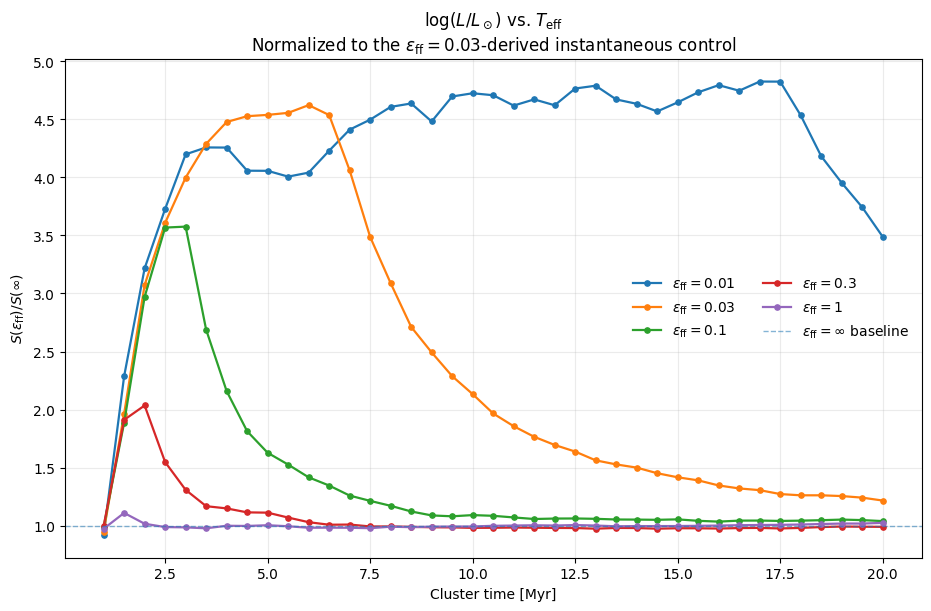

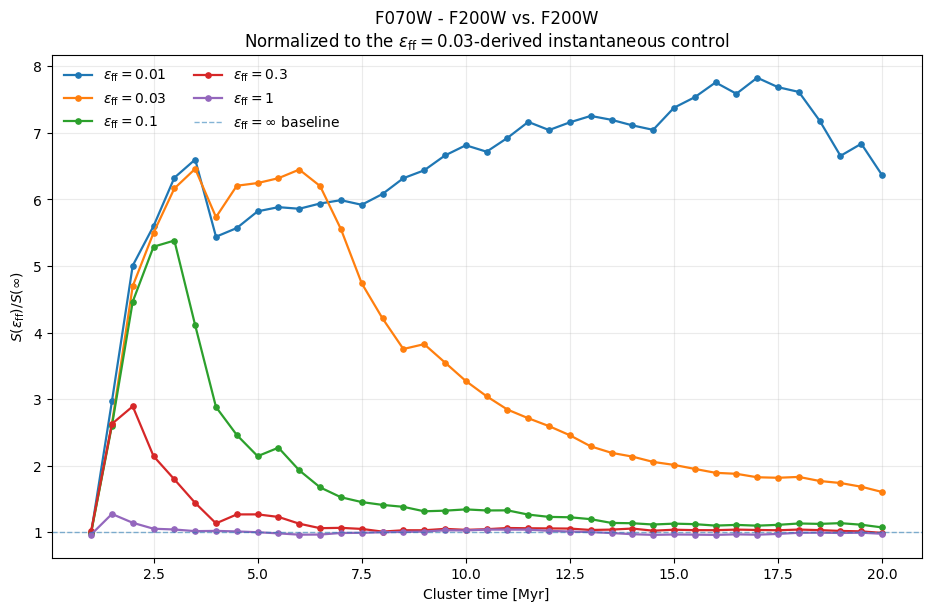

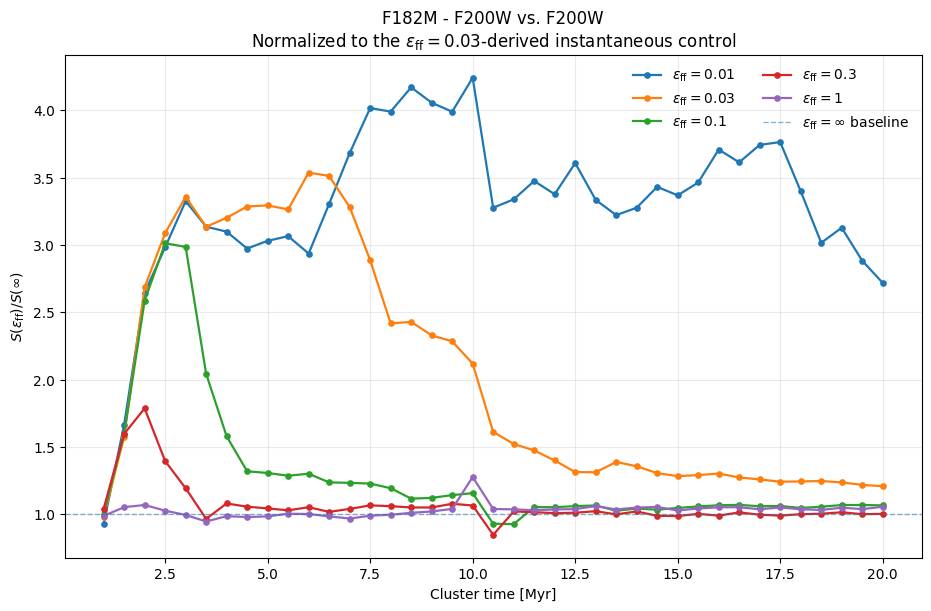

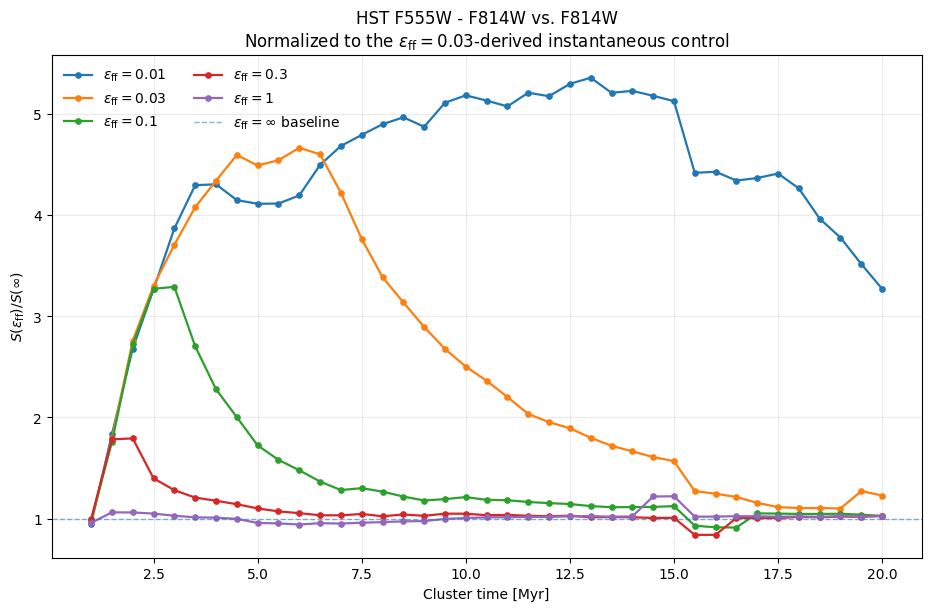

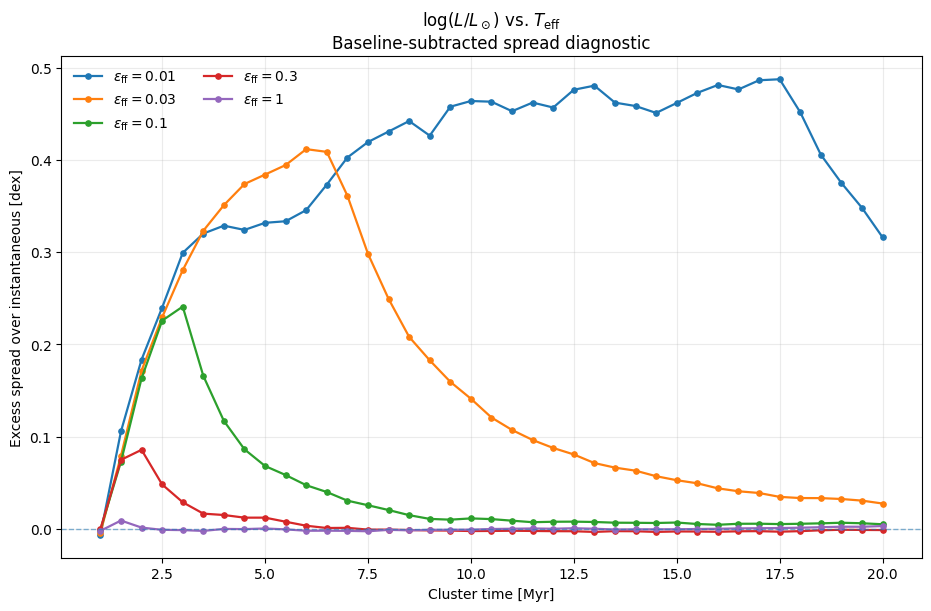

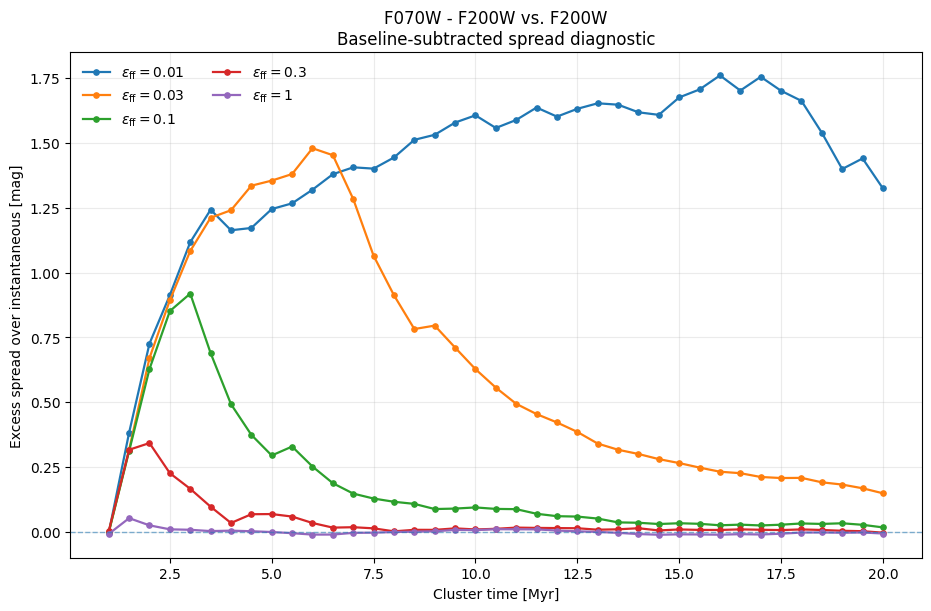

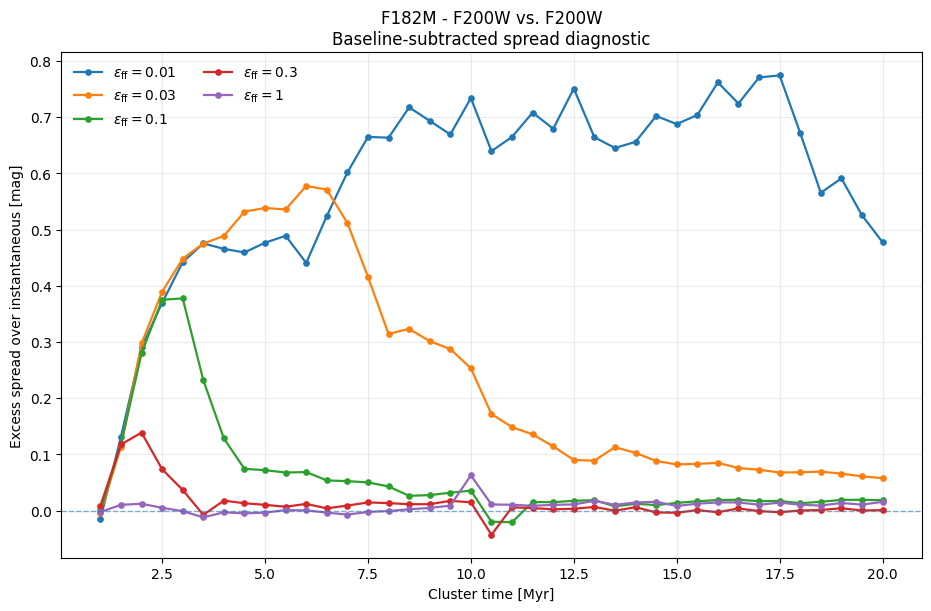

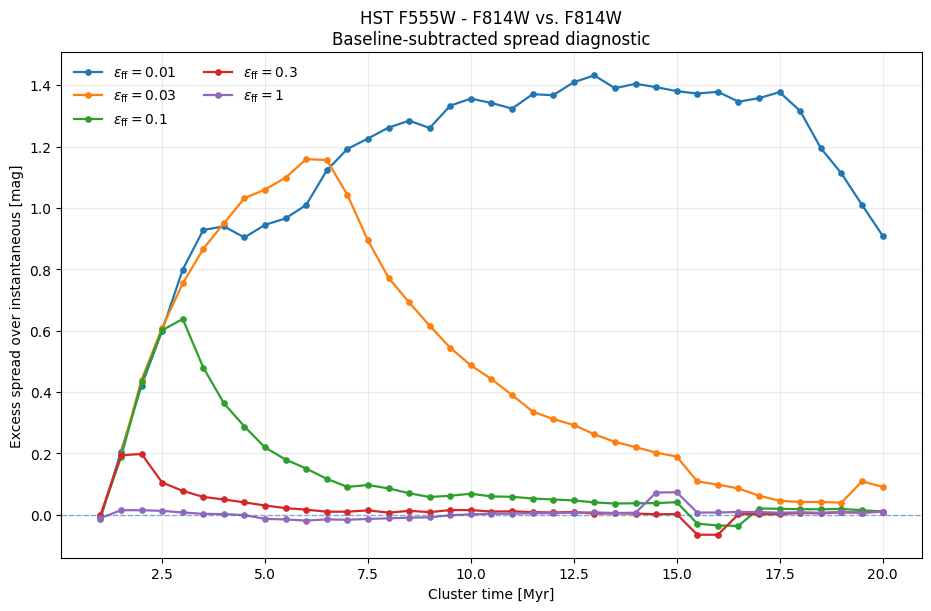

In [22]:
normalization_rows = []

for diagram in DIAGRAMS:
    baseline = (
        df_metrics[
            (df_metrics['case'] == INFINITE)
            & (df_metrics['diagram'] == diagram.key)
        ][['snapshot_time_myr', 'spread_metric']]
        .rename(columns={'spread_metric': 'instantaneous_spread'})
    )

    for eff in EFF_CONFIG:
        case = FINITE_CASES[eff]
        finite = (
            df_metrics[
                (df_metrics['case'] == case)
                & (df_metrics['diagram'] == diagram.key)
            ][['snapshot_time_myr', 'spread_metric', 'n_valid_bins']]
            .rename(columns={
                'spread_metric': 'finite_spread',
                'n_valid_bins': 'finite_n_valid_bins',
            })
        )

        merged = finite.merge(baseline, on='snapshot_time_myr', how='left')
        good_baseline = (
            np.isfinite(merged['instantaneous_spread'])
            & (merged['instantaneous_spread'] > NORMALIZATION_MIN_BASELINE)
        )
        good_finite = np.isfinite(merged['finite_spread'])
        good_ratio = good_baseline & good_finite

        normalized = np.full(len(merged), np.nan, dtype=float)
        normalized[good_ratio.to_numpy()] = (
            merged.loc[good_ratio, 'finite_spread'].to_numpy(float)
            / merged.loc[good_ratio, 'instantaneous_spread'].to_numpy(float)
        )
        excess = merged['finite_spread'] - merged['instantaneous_spread']

        for j, row in merged.reset_index(drop=True).iterrows():
            normalization_rows.append({
                'diagram': diagram.key,
                'diagram_title': diagram.title,
                'epsilon_ff': eff,
                'case': case,
                'snapshot_time_myr': row['snapshot_time_myr'],
                'finite_spread': row['finite_spread'],
                'instantaneous_spread': row['instantaneous_spread'],
                'normalized_to_instantaneous': normalized[j],
                'excess_over_instantaneous': excess.iloc[j],
                'finite_n_valid_bins': row['finite_n_valid_bins'],
                'normalization_valid': bool(good_ratio.iloc[j]),
            })


df_normalized = pd.DataFrame(normalization_rows)
df_normalized.to_csv(
    OUTPUT_DIR / 'spread_normalized_to_instantaneous.csv', index=False
)
df_normalized.to_csv(
    METRIC_DIR / 'spread_normalized_to_instantaneous.csv', index=False
)

for diagram in DIAGRAMS:
    fig, ax = plt.subplots(figsize=(9.2, 6.0), constrained_layout=True)
    for eff in EFF_CONFIG:
        sub = (
            df_normalized[
                (df_normalized['epsilon_ff'] == eff)
                & (df_normalized['diagram'] == diagram.key)
            ]
            .sort_values('snapshot_time_myr')
        )
        ax.plot(
            sub['snapshot_time_myr'],
            sub['normalized_to_instantaneous'],
            marker='o', ms=3.8, lw=1.6,
            label=CASE_LABEL[FINITE_CASES[eff]],
        )

    ax.axhline(
        1.0, lw=1.0, ls='--', alpha=0.55,
        label=r'$\epsilon_{\rm ff}=\infty$ baseline',
    )
    ax.set_xlabel('Cluster time [Myr]')
    ax.set_ylabel(r'$S(\epsilon_{\rm ff}) / S(\infty)$')
    ax.set_title(
        diagram.title
        + '\nNormalized to the '
        + r'$\epsilon_{\rm ff}=0.03$'
        + '-derived instantaneous control'
    )
    ax.grid(alpha=0.25)
    ax.legend(frameon=False, ncol=2)
    finish_figure(fig, f'spread_normalized_all_eff_{diagram.key}.png')

# Baseline-subtracted diagnostic.
for diagram in DIAGRAMS:
    fig, ax = plt.subplots(figsize=(9.2, 6.0), constrained_layout=True)
    for eff in EFF_CONFIG:
        sub = (
            df_normalized[
                (df_normalized['epsilon_ff'] == eff)
                & (df_normalized['diagram'] == diagram.key)
            ]
            .sort_values('snapshot_time_myr')
        )
        ax.plot(
            sub['snapshot_time_myr'],
            sub['excess_over_instantaneous'],
            marker='o', ms=3.8, lw=1.6,
            label=CASE_LABEL[FINITE_CASES[eff]],
        )

    ax.axhline(0.0, lw=1.0, ls='--', alpha=0.55)
    unit = 'dex' if diagram.kind == 'hr' else 'mag'
    ax.set_xlabel('Cluster time [Myr]')
    ax.set_ylabel(f'Excess spread over instantaneous [{unit}]')
    ax.set_title(diagram.title + '\nBaseline-subtracted spread diagnostic')
    ax.grid(alpha=0.25)
    ax.legend(frameon=False, ncol=2)
    finish_figure(fig, f'spread_excess_over_instantaneous_{diagram.key}.png')

## Temperature-contamination fraction versus time

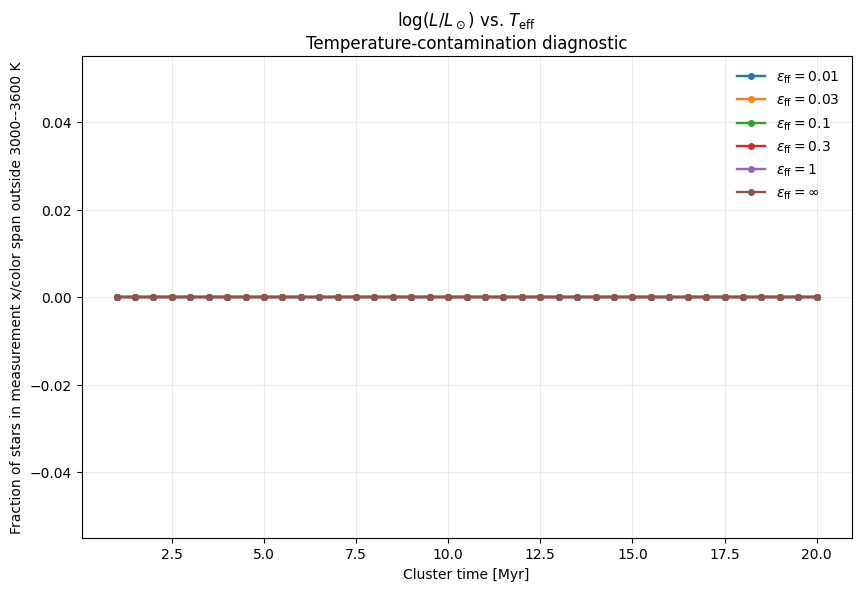

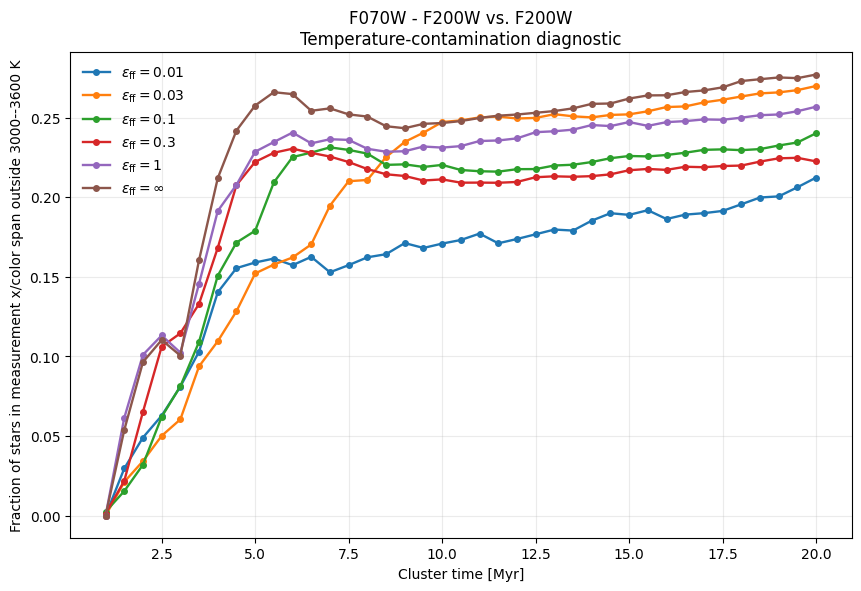

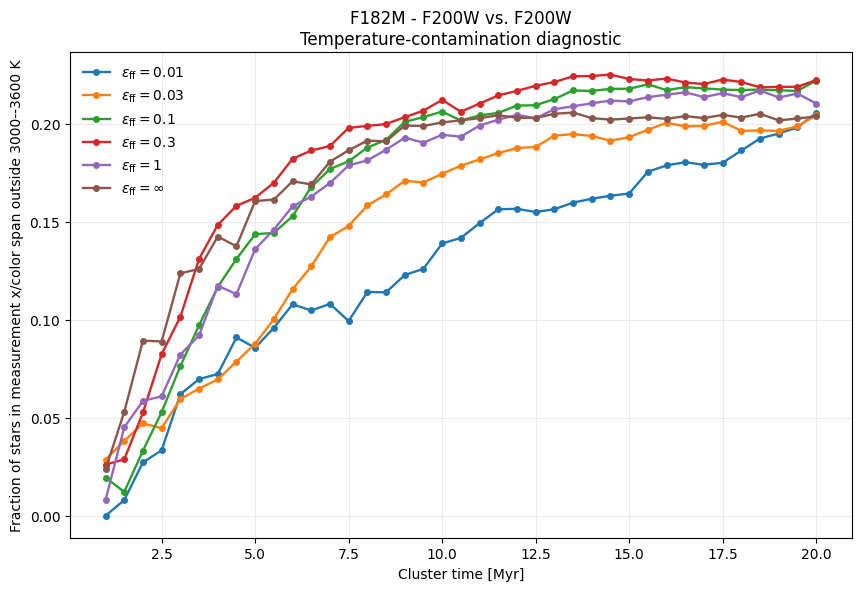

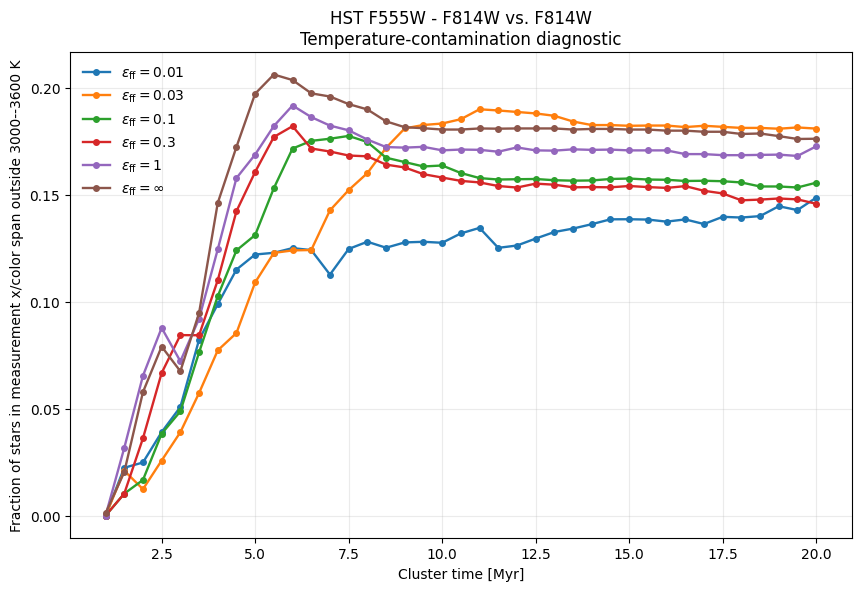

In [23]:
for diagram in DIAGRAMS:
    fig, ax = plt.subplots(
        figsize=(8.5, 5.8),
        constrained_layout=True,
    )

    for case in CASE_ORDER:
        sub = (
            df_metrics[
                (
                    df_metrics[
                        'case'
                    ] == case
                )
                & (
                    df_metrics[
                        'diagram'
                    ] == diagram.key
                )
            ]
            .sort_values(
                'snapshot_time_myr'
            )
        )

        ax.plot(
            sub[
                'snapshot_time_myr'
            ],
            sub[
                'fraction_full_x_span_rejected_by_teff'
            ],
            marker='o',
            ms=4,
            lw=1.7,
            label=CASE_LABEL[
                case
            ],
        )

    ax.set_xlabel(
        'Cluster time [Myr]'
    )

    ax.set_ylabel(
        'Fraction of stars in measurement '
        'x/color span outside 3000--3600 K'
    )

    ax.set_title(
        diagram.title
        + '\nTemperature-contamination diagnostic'
    )

    ax.grid(
        alpha=0.25
    )

    ax.legend(
        frameon=False
    )

    finish_figure(
        fig,
        f'temperature_contamination_{diagram.key}.png',
    )

## Delta t90 validation plot

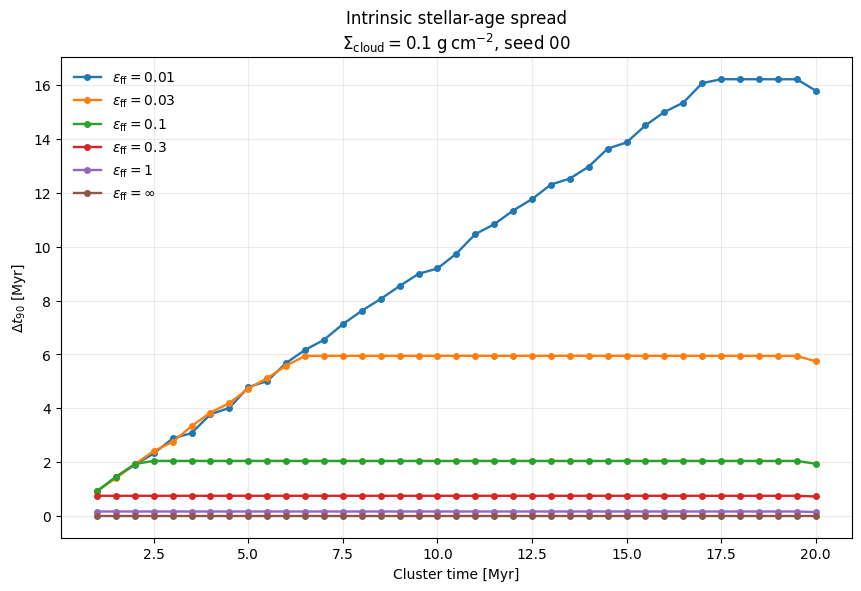

In [24]:
age_table = (
    df_metrics[
        [
            'case',
            'snapshot_time_myr',
            'age_spread_p95_minus_p05_myr',
        ]
    ]
    .drop_duplicates()
    .sort_values(
        [
            'case',
            'snapshot_time_myr',
        ]
    )
)

fig, ax = plt.subplots(
    figsize=(8.5, 5.8),
    constrained_layout=True,
)

for case in CASE_ORDER:
    sub = age_table[
        age_table[
            'case'
        ] == case
    ]

    ax.plot(
        sub[
            'snapshot_time_myr'
        ],
        sub[
            'age_spread_p95_minus_p05_myr'
        ],
        marker='o',
        ms=4,
        lw=1.7,
        label=CASE_LABEL[
            case
        ],
    )

ax.set_xlabel(
    'Cluster time [Myr]'
)

ax.set_ylabel(
    r'$\Delta t_{90}$ [Myr]'
)

ax.set_title(
    'Intrinsic stellar-age spread\n'
    + r'$\Sigma_{\rm cloud}=0.1\ {\rm g\,cm^{-2}}$, seed 00'
)

ax.grid(
    alpha=0.25
)

ax.legend(
    frameon=False
)

finish_figure(
    fig,
    'age_spread_finite_vs_infinite.png',
)

## Metadata

In [25]:
metadata = {
    'simulation_root': str(SIMULATION_ROOT),
    'simulation_paths': {str(eff): str(path) for eff, path in SIMULATION_PATHS.items()},
    'sigma_cloud_g_cm2': 0.1,
    'finite_epsilon_ff_values': [float(eff) for eff in EFF_CONFIG],
    'seed': SEED,
    'instantaneous_source_epsilon_ff': INSTANTANEOUS_SOURCE_EFF,
    'instantaneous_source_path': str(INSTANTANEOUS_SOURCE_PATH),

    'temperature_selection': (
        'Global catalog-star cut: '
        '3000 <= Teff <= 3600 K.'
    ),

    'reference_bin_age_myr': REFERENCE_BIN_AGE_MYR,

    'cmd_bin_definition': (
        'For each CMD, use the 1 Myr isochrone to interpolate the color '
        'at Teff=3000 K and Teff=3600 K, divide the interval between '
        'those two colors into six equal-width bins, and reuse the same '
        'fixed color edges at every cluster age.'
    ),

    'catalog_star_assignment': (
        'Stars first pass the global 3000<=Teff<=3600 K eligibility cut. '
        'Eligible stars are then assigned to the six CMD bins solely by '
        'their actual synthetic colors.'
    ),

    'hr_bin_definition': (
        'Six fixed equal-width Teff bins from 3000 to 3600 K.'
    ),

    'isochrone_plotting': (
        'Scatter points only; no connected line through a boolean-selected '
        'isochrone subset, preventing artificial connections across '
        'disconnected branches.'
    ),

    'analysis_times_myr': (
        ANALYSIS_TIMES_MYR.tolist()
    ),

    'isochrone_ages_myr': (
        ISO_AGES_MYR.tolist()
    ),

    'teff_min_k': TEFF_MIN_K,
    'teff_max_k': TEFF_MAX_K,
    'n_bins': N_BINS,

    'normalization_definition': (
        'finite spread divided by the single epsilon_ff=0.03-derived '
        'instantaneous spread at the same time and in the same diagram'
    ),
    'normalization_min_baseline': NORMALIZATION_MIN_BASELINE,

    'minimum_stars_per_bin': (
        MIN_STARS_PER_BIN
    ),

    'filters': FILTER_OBSMODES,

    'diagrams': [
        asdict(
            diagram
        )
        for diagram in DIAGRAMS
    ],
}

(
    OUTPUT_DIR
    / 'analysis_metadata.json'
).write_text(
    json.dumps(
        metadata,
        indent=2,
    )
)

print()
print(
    f'Outputs: '
    f'{OUTPUT_DIR.resolve()}'
)
print(
    f'Analysis cache: '
    f'{CACHE_DIR.resolve()}'
)
print(
    f'Static-bin metric cache: '
    f'{METRIC_DIR.resolve()}'
)
print(
    'Maximum instantaneous Delta t90:',
    max_instantaneous_dt90,
)


Outputs: /sfs/gpfs/tardis/home/wyz5rge/synthetic-cmd-dev/notebooks/2026/08-10_one-seed-multiple-e_ff/seed00_all_eff_static_1myr_bins_outputs
Analysis cache: /sfs/gpfs/tardis/home/wyz5rge/synthetic-cmd-dev/notebooks/2026/08-10_one-seed-multiple-e_ff/analysis_cache_all_eff_seed00
Static-bin metric cache: /sfs/gpfs/tardis/home/wyz5rge/synthetic-cmd-dev/notebooks/2026/08-10_one-seed-multiple-e_ff/analysis_cache_all_eff_seed00/metrics_static_1myr_color_bins
Maximum instantaneous Delta t90: 0.0
